# Modelo de IA para programas de Medicina en Saber Pro

Proyecto de especialización en Inteligencia Artificial.

**Objetivo general:** analizar y predecir el desempeño de los programas de Medicina en Colombia a partir de datos históricos del ICFES/Saber Pro, usando Machine Learning e IA Explicable.

**Variable objetivo inicial:** `PROMEDIO_GLOBAL`.

## Flujo de trabajo por etapas

1. Comprensión del negocio.
2. Comprensión del dataset.
3. EDA documentado.
4. Ingeniería de características.
5. Entrenamiento y comparación de modelos.
6. Validación.
7. IA Explicable con SHAP.
8. Recomendaciones.
9. Dashboard / sistema final.

En esta primera versión avanzamos con las etapas **1 y 2**.

## 1. Comprensión del negocio

Saber Pro es una prueba estandarizada aplicada en Colombia para evaluar competencias de estudiantes próximos a finalizar programas de educación superior.

Para este proyecto, el interés está en los programas asociados al NBC **Medicina**. El problema no es solo describir puntajes, sino construir una base analítica que permita:

- observar la evolución histórica del desempeño;
- comparar instituciones, regiones y departamentos;
- detectar variabilidad o estabilidad en resultados;
- predecir el comportamiento futuro del desempeño;
- explicar qué variables influyen en las predicciones;
- generar recomendaciones basadas en evidencia.

El aporte de IA será transformar datos históricos en predicciones interpretables y recomendaciones útiles para la toma de decisiones académicas.

In [1]:
# Imports básicos
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_theme(style='whitegrid')


In [2]:
# Cargar dataset desde archivo local, Colab o Google Sheets/Drive
# Orden de búsqueda:
# 1) CSV en la misma carpeta del notebook (útil en VS Code/local)
# 2) CSV subido a /content en Colab
# 3) CSV en MyDrive
# 4) Enlace público de Google Sheets exportado como CSV

from pathlib import Path

sheet_id = '183VPzuoWWNPnmY5pfBpC9DOowLgCU7Kbgb2Q64Lh9Qo'
csv_url = f'https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv'

possible_paths = [
    Path('saber_pro_limpio(in).csv'),
    Path('saber_pro_limpio.csv'),
    Path('/content/saber_pro_limpio(in).csv'),
    Path('/content/saber_pro_limpio.csv'),
    Path('/content/drive/MyDrive/saber_pro_limpio(in).csv'),
    Path('/content/drive/MyDrive/saber_pro_limpio.csv'),
]

csv_path = next((p for p in possible_paths if p.exists()), None)

if csv_path is not None:
    df = pd.read_csv(csv_path)
    fuente_datos = str(csv_path)
else:
    df = pd.read_csv(csv_url)
    fuente_datos = csv_url

print(f'Fuente de datos: {fuente_datos}')
print(f'Filas: {df.shape[0]}')
print(f'Columnas: {df.shape[1]}')
df.head()

Fuente de datos: saber_pro_limpio(in).csv
Filas: 127716
Columnas: 24


,AÑO,ID_PAIS,ID_REGION,NOMBRE_REGION,ID_DEPARTAMENTO,NOMBRE_DEPARTAMENTO,ID_MUNICIPIO,NOMBRE_MUNICIPIO,ID_INSTITUCION,NOMBRE_INSTITUCION,ID_NBC,NBC,ID_PROGRAMA_ACAD,NOMBRE_PROGRAMA_ACAD,NOMBRE_PRUEBA,CATEGORIAPRUEBA,CANTIDADEVALUADOS,PROMEDIO_PRUEBA,DESVIACION,PROMEDIO_GLOBAL,NIVEL1,NIVEL2,NIVEL3,NIVEL4
0,2020,1.0,1.0,AMAZONÍA,8.0,CAQUETA,349.0,FLORENCIA,9105.0,UNIVERSIDAD DE LA AMAZONIA,13.0,EDUCACIÓN,1456.0,LICENCIATURA EN LENGUA CASTELLANA Y LITERATURA,COMPETENCIAS CIUDADANAS,1.0,26.0,135.0,24.0,133.0,27.0,54.0,19.0,0.0
1,2020,1.0,1.0,AMAZONÍA,8.0,CAQUETA,349.0,FLORENCIA,9105.0,UNIVERSIDAD DE LA AMAZONIA,59.0,DERECHO Y AFINES,2660.0,DERECHO,RAZONAMIENTO CUANTITATIVO,1.0,108.0,143.0,24.0,146.0,23.0,45.0,31.0,0.0
2,2020,1.0,1.0,AMAZONÍA,8.0,CAQUETA,349.0,FLORENCIA,9105.0,UNIVERSIDAD DE LA AMAZONIA,13.0,EDUCACIÓN,6443.0,LICENCIATURA EN INGLES,INGLÉS,1.0,56.0,196.0,30.0,161.0,2.0,0.0,2.0,43.0
3,2020,1.0,1.0,AMAZONÍA,8.0,CAQUETA,349.0,FLORENCIA,9105.0,UNIVERSIDAD DE LA AMAZONIA,9.0,ADMINISTRACIÓN,4575.0,ADMINISTRACION FINANCIERA,COMUNICACIÓN ESCRITA,1.0,9.0,131.0,56.0,127.0,13.0,25.0,63.0,0.0
4,2020,1.0,1.0,AMAZONÍA,8.0,CAQUETA,349.0,FLORENCIA,9105.0,UNIVERSIDAD DE LA AMAZONIA,13.0,EDUCACIÓN,6443.0,LICENCIATURA EN INGLES,COMPETENCIAS CIUDADANAS,1.0,56.0,157.0,28.0,161.0,14.0,23.0,57.0,5.0


In [3]:
# Filtrar solo registros de Medicina
# En el dataset la columna NBC contiene valores como 'MEDICINA' y 'MEDICINA VETERINARIA'.
# Para este proyecto usamos coincidencia exacta con MEDICINA.

solo_medicina = df[
    df['NBC'].astype(str).str.upper().eq('MEDICINA') &
    df['NOMBRE_PROGRAMA_ACAD'].astype(str).str.upper().str.contains('MEDICINA')
].copy()

print(f'Filas medicina: {solo_medicina.shape[0]}')
print(f'Columnas: {solo_medicina.shape[1]}')
solo_medicina.head()

Filas medicina: 2173
Columnas: 24


,AÑO,ID_PAIS,ID_REGION,NOMBRE_REGION,ID_DEPARTAMENTO,NOMBRE_DEPARTAMENTO,ID_MUNICIPIO,NOMBRE_MUNICIPIO,ID_INSTITUCION,NOMBRE_INSTITUCION,ID_NBC,NBC,ID_PROGRAMA_ACAD,NOMBRE_PROGRAMA_ACAD,NOMBRE_PRUEBA,CATEGORIAPRUEBA,CANTIDADEVALUADOS,PROMEDIO_PRUEBA,DESVIACION,PROMEDIO_GLOBAL,NIVEL1,NIVEL2,NIVEL3,NIVEL4
763,2020,1.0,2.0,ANDINA,1.0,ANTIOQUIA,1.0,MEDELLÍN,8894.0,UNIVERSIDAD DE ANTIOQUIA,45.0,MEDICINA,6217.0,MEDICINA,RAZONAMIENTO CUANTITATIVO,1.0,234.0,192.0,25.0,187.0,2.0,5.0,55.0,38.0
772,2020,1.0,2.0,ANDINA,1.0,ANTIOQUIA,1.0,MEDELLÍN,8894.0,UNIVERSIDAD DE ANTIOQUIA,45.0,MEDICINA,6217.0,MEDICINA,COMUNICACIÓN ESCRITA,1.0,234.0,168.0,48.0,187.0,5.0,23.0,38.0,34.0
792,2020,1.0,2.0,ANDINA,1.0,ANTIOQUIA,1.0,MEDELLÍN,8894.0,UNIVERSIDAD DE ANTIOQUIA,45.0,MEDICINA,6217.0,MEDICINA,COMPETENCIAS CIUDADANAS,1.0,234.0,190.0,31.0,187.0,3.0,7.0,60.0,30.0
840,2020,1.0,2.0,ANDINA,1.0,ANTIOQUIA,1.0,MEDELLÍN,8894.0,UNIVERSIDAD DE ANTIOQUIA,45.0,MEDICINA,6217.0,MEDICINA,LECTURA CRÍTICA,1.0,234.0,190.0,25.0,187.0,3.0,6.0,60.0,32.0
953,2020,1.0,2.0,ANDINA,1.0,ANTIOQUIA,1.0,MEDELLÍN,8894.0,UNIVERSIDAD DE ANTIOQUIA,45.0,MEDICINA,6217.0,MEDICINA,INGLÉS,1.0,234.0,194.0,29.0,187.0,1.0,2.0,9.0,47.0


## 2. Comprensión del dataset

En esta etapa revisamos estructura, tipos de datos, columnas categóricas, numéricas, temporales y geográficas. También identificamos faltantes, duplicados, inconsistencias iniciales y posibles riesgos de fuga de información (*data leakage*).

In [4]:
# Columnas disponibles
solo_medicina.columns.tolist()

['AÑO',
 'ID_PAIS',
 'ID_REGION',
 'NOMBRE_REGION',
 'ID_DEPARTAMENTO',
 'NOMBRE_DEPARTAMENTO',
 'ID_MUNICIPIO',
 'NOMBRE_MUNICIPIO',
 'ID_INSTITUCION',
 'NOMBRE_INSTITUCION',
 'ID_NBC',
 'NBC',
 'ID_PROGRAMA_ACAD',
 'NOMBRE_PROGRAMA_ACAD',
 'NOMBRE_PRUEBA',
 'CATEGORIAPRUEBA',
 'CANTIDADEVALUADOS',
 'PROMEDIO_PRUEBA',
 'DESVIACION',
 'PROMEDIO_GLOBAL',
 'NIVEL1',
 'NIVEL2',
 'NIVEL3',
 'NIVEL4']

In [5]:
# Tipos de datos
solo_medicina.dtypes.to_frame('tipo_dato')

,tipo_dato
AÑO,str
ID_PAIS,float64
ID_REGION,float64
NOMBRE_REGION,str
ID_DEPARTAMENTO,float64
NOMBRE_DEPARTAMENTO,str
ID_MUNICIPIO,float64
NOMBRE_MUNICIPIO,str
ID_INSTITUCION,float64
NOMBRE_INSTITUCION,str


In [6]:
# Clasificación inicial de variables
columnas_temporales = ['AÑO']
columnas_geograficas = [
    'ID_PAIS', 'ID_REGION', 'NOMBRE_REGION',
    'ID_DEPARTAMENTO', 'NOMBRE_DEPARTAMENTO',
    'ID_MUNICIPIO', 'NOMBRE_MUNICIPIO'
]
columnas_institucion = ['ID_INSTITUCION', 'NOMBRE_INSTITUCION']
columnas_programa = ['ID_NBC', 'NBC', 'ID_PROGRAMA_ACAD', 'NOMBRE_PROGRAMA_ACAD']
columnas_prueba = ['NOMBRE_PRUEBA', 'CATEGORIAPRUEBA']
columnas_numericas_resultado = [
    'CANTIDADEVALUADOS', 'PROMEDIO_PRUEBA', 'DESVIACION',
    'PROMEDIO_GLOBAL', 'NIVEL1', 'NIVEL2', 'NIVEL3', 'NIVEL4'
]

resumen_variables = pd.DataFrame({
    'grupo': (
        ['temporal'] * len(columnas_temporales) +
        ['geografica'] * len(columnas_geograficas) +
        ['institucion'] * len(columnas_institucion) +
        ['programa'] * len(columnas_programa) +
        ['prueba'] * len(columnas_prueba) +
        ['resultado'] * len(columnas_numericas_resultado)
    ),
    'columna': (
        columnas_temporales + columnas_geograficas + columnas_institucion +
        columnas_programa + columnas_prueba + columnas_numericas_resultado
    )
})

resumen_variables

,grupo,columna
0,temporal,AÑO
1,geografica,ID_PAIS
2,geografica,ID_REGION
3,geografica,NOMBRE_REGION
4,geografica,ID_DEPARTAMENTO
5,geografica,NOMBRE_DEPARTAMENTO
6,geografica,ID_MUNICIPIO
7,geografica,NOMBRE_MUNICIPIO
8,institucion,ID_INSTITUCION
9,institucion,NOMBRE_INSTITUCION


In [7]:
# Valores faltantes
faltantes = solo_medicina.isna().sum().to_frame('faltantes')
faltantes['porcentaje'] = (faltantes['faltantes'] / len(solo_medicina) * 100).round(2)
faltantes.sort_values('faltantes', ascending=False)

,faltantes,porcentaje
DESVIACION,27,1.24
AÑO,0,0.00
ID_PAIS,0,0.00
NIVEL3,0,0.00
NIVEL2,0,0.00
NIVEL1,0,0.00
PROMEDIO_GLOBAL,0,0.00
PROMEDIO_PRUEBA,0,0.00
CANTIDADEVALUADOS,0,0.00
CATEGORIAPRUEBA,0,0.00


In [8]:
# Duplicados exactos
duplicados = solo_medicina.duplicated().sum()
print(f'Duplicados exactos: {duplicados}')

Duplicados exactos: 0


In [9]:
# Valores únicos por columna
unicos = solo_medicina.nunique(dropna=False).to_frame('valores_unicos')
unicos.sort_values('valores_unicos', ascending=False)

,valores_unicos
CANTIDADEVALUADOS,203
PROMEDIO_PRUEBA,129
NIVEL4,88
NIVEL3,88
NIVEL1,88
ID_PROGRAMA_ACAD,70
NIVEL2,68
DESVIACION,66
PROMEDIO_GLOBAL,62
ID_INSTITUCION,49


In [10]:
# Rango temporal disponible
solo_medicina['AÑO'].agg(['min', 'max']).to_frame('AÑO')

,AÑO
min,2020
max,2024


In [11]:
# Estadística descriptiva de variables numéricas principales
solo_medicina[columnas_numericas_resultado].describe().T

,count,mean,std,min,25%,50%,75%,max
CANTIDADEVALUADOS,2173.0,112.797515,72.855261,1.0,60.0,105.0,150.0,396.0
PROMEDIO_PRUEBA,2173.0,162.117349,21.273834,42.0,149.0,162.0,176.0,230.0
DESVIACION,2146.0,28.787978,9.431993,0.0,24.0,27.0,32.0,107.0
PROMEDIO_GLOBAL,2173.0,164.660377,15.472773,113.0,152.0,163.0,175.0,199.0
NIVEL1,2173.0,12.618500,16.857254,0.0,2.0,7.0,16.0,100.0
NIVEL2,2173.0,26.098942,17.146049,0.0,12.0,26.0,37.0,100.0
NIVEL3,2173.0,45.560055,19.527138,0.0,34.0,46.0,59.0,100.0
NIVEL4,2173.0,15.113208,17.099968,0.0,3.0,9.0,22.0,100.0


## Variable objetivo y predictores iniciales

La variable objetivo inicial será:

- `PROMEDIO_GLOBAL`

Variables que deben tratarse con cuidado por posible fuga de información:

- `PROMEDIO_PRUEBA`: puede estar muy relacionada con el desempeño observado.
- `NIVEL1`, `NIVEL2`, `NIVEL3`, `NIVEL4`: describen distribución de resultados y podrían revelar información posterior al examen.
- `DESVIACION`: también es estadística derivada del resultado.

Para un primer modelo predictivo conservador, conviene empezar con variables históricas, geográficas, institucionales, programa, año y cantidad de evaluados. Luego se puede comparar contra modelos más informados, documentando el riesgo de leakage.

In [12]:
# Configuración inicial del problema predictivo
TARGET = 'PROMEDIO_GLOBAL'

posibles_predictoras_base = [
    'AÑO',
    'ID_REGION', 'NOMBRE_REGION',
    'ID_DEPARTAMENTO', 'NOMBRE_DEPARTAMENTO',
    'ID_MUNICIPIO', 'NOMBRE_MUNICIPIO',
    'ID_INSTITUCION', 'NOMBRE_INSTITUCION',
    'ID_PROGRAMA_ACAD', 'NOMBRE_PROGRAMA_ACAD',
    'NOMBRE_PRUEBA', 'CATEGORIAPRUEBA',
    'CANTIDADEVALUADOS'
]

variables_con_riesgo_leakage = [
    'PROMEDIO_PRUEBA', 'DESVIACION', 'NIVEL1', 'NIVEL2', 'NIVEL3', 'NIVEL4'
]

print('Target:', TARGET)
print('\nPredictoras base:')
print(posibles_predictoras_base)
print('\nVariables con posible leakage:')
print(variables_con_riesgo_leakage)


Target: PROMEDIO_GLOBAL

Predictoras base:
['AÑO', 'ID_REGION', 'NOMBRE_REGION', 'ID_DEPARTAMENTO', 'NOMBRE_DEPARTAMENTO', 'ID_MUNICIPIO', 'NOMBRE_MUNICIPIO', 'ID_INSTITUCION', 'NOMBRE_INSTITUCION', 'ID_PROGRAMA_ACAD', 'NOMBRE_PROGRAMA_ACAD', 'NOMBRE_PRUEBA', 'CATEGORIAPRUEBA', 'CANTIDADEVALUADOS']

Variables con posible leakage:
['PROMEDIO_PRUEBA', 'DESVIACION', 'NIVEL1', 'NIVEL2', 'NIVEL3', 'NIVEL4']


In [13]:
# Dataset inicial para modelado conservador
model_data = solo_medicina[posibles_predictoras_base + [TARGET]].dropna(subset=[TARGET]).copy()

print(f'Filas para modelado inicial: {model_data.shape[0]}')
print(f'Columnas para modelado inicial: {model_data.shape[1]}')
model_data.head()

Filas para modelado inicial: 2173
Columnas para modelado inicial: 15


,AÑO,ID_REGION,NOMBRE_REGION,ID_DEPARTAMENTO,NOMBRE_DEPARTAMENTO,ID_MUNICIPIO,NOMBRE_MUNICIPIO,ID_INSTITUCION,NOMBRE_INSTITUCION,ID_PROGRAMA_ACAD,NOMBRE_PROGRAMA_ACAD,NOMBRE_PRUEBA,CATEGORIAPRUEBA,CANTIDADEVALUADOS,PROMEDIO_GLOBAL
763,2020,2.0,ANDINA,1.0,ANTIOQUIA,1.0,MEDELLÍN,8894.0,UNIVERSIDAD DE ANTIOQUIA,6217.0,MEDICINA,RAZONAMIENTO CUANTITATIVO,1.0,234.0,187.0
772,2020,2.0,ANDINA,1.0,ANTIOQUIA,1.0,MEDELLÍN,8894.0,UNIVERSIDAD DE ANTIOQUIA,6217.0,MEDICINA,COMUNICACIÓN ESCRITA,1.0,234.0,187.0
792,2020,2.0,ANDINA,1.0,ANTIOQUIA,1.0,MEDELLÍN,8894.0,UNIVERSIDAD DE ANTIOQUIA,6217.0,MEDICINA,COMPETENCIAS CIUDADANAS,1.0,234.0,187.0
840,2020,2.0,ANDINA,1.0,ANTIOQUIA,1.0,MEDELLÍN,8894.0,UNIVERSIDAD DE ANTIOQUIA,6217.0,MEDICINA,LECTURA CRÍTICA,1.0,234.0,187.0
953,2020,2.0,ANDINA,1.0,ANTIOQUIA,1.0,MEDELLÍN,8894.0,UNIVERSIDAD DE ANTIOQUIA,6217.0,MEDICINA,INGLÉS,1.0,234.0,187.0


## 3. Análisis Exploratorio de Datos (EDA)

Esta etapa estudia el comportamiento de los programas de Medicina antes de construir modelos predictivos. El objetivo es identificar distribución del desempeño, evolución temporal, diferencias geográficas e institucionales, posibles outliers y relación entre cantidad de evaluados y desempeño global.

In [14]:
# Preparar copia para EDA
eda_data = solo_medicina.copy()
eda_data['AÑO'] = pd.to_numeric(eda_data['AÑO'], errors='coerce').astype('Int64')

print(f'Filas para EDA: {eda_data.shape[0]}')
print(f'Columnas para EDA: {eda_data.shape[1]}')
print(f'Años disponibles: {eda_data["AÑO"].min()} - {eda_data["AÑO"].max()}')

Filas para EDA: 2173
Columnas para EDA: 24
Años disponibles: 2020 - 2024


### 3.1 Distribución de `PROMEDIO_GLOBAL`

El histograma permite ver dónde se concentra el desempeño global. El boxplot complementa la lectura mostrando mediana, dispersión y valores atípicos potenciales.

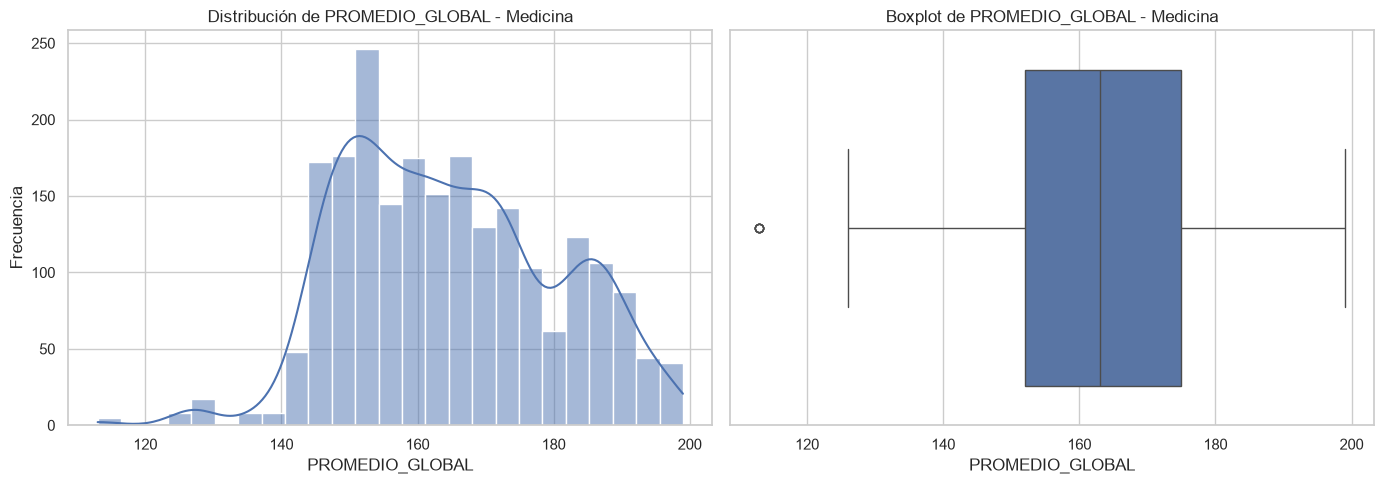

,PROMEDIO_GLOBAL
count,2173.000000
mean,164.660377
std,15.472773
min,113.000000
25%,152.000000
50%,163.000000
75%,175.000000
max,199.000000


In [15]:
# Distribución de PROMEDIO_GLOBAL
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=eda_data, x=TARGET, bins=25, kde=True, ax=axes[0])
axes[0].set_title('Distribución de PROMEDIO_GLOBAL - Medicina')
axes[0].set_xlabel('PROMEDIO_GLOBAL')
axes[0].set_ylabel('Frecuencia')

sns.boxplot(data=eda_data, x=TARGET, ax=axes[1])
axes[1].set_title('Boxplot de PROMEDIO_GLOBAL - Medicina')
axes[1].set_xlabel('PROMEDIO_GLOBAL')

plt.tight_layout()
plt.show()

eda_data[TARGET].describe().to_frame('PROMEDIO_GLOBAL')

**Nota de interpretación:** revisá si la distribución es simétrica o si tiene cola hacia valores bajos/altos. La mediana y los cuartiles ayudan a entender el rango típico de desempeño de Medicina.

### 3.2 Evolución anual 2020-2024

Esta vista muestra si el desempeño global promedio de Medicina mejora, cae o permanece estable a lo largo del tiempo.

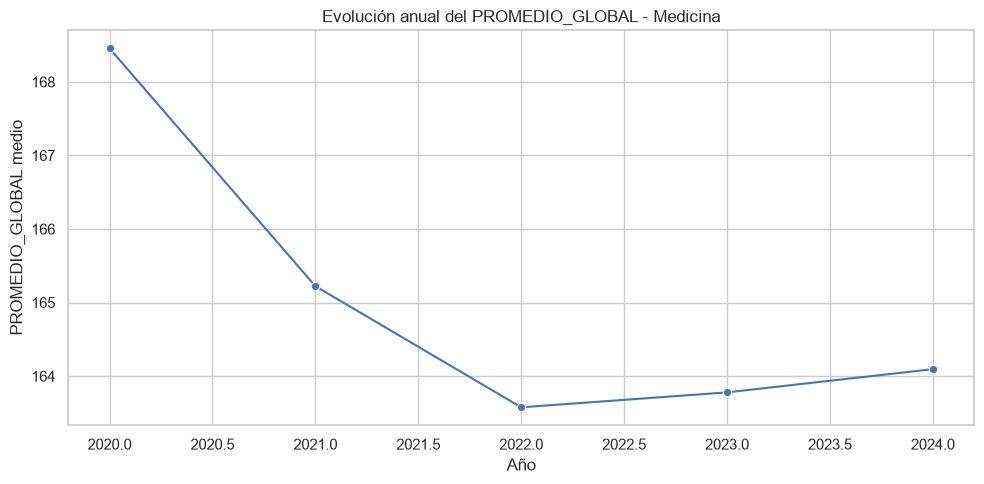

,AÑO,promedio_global_medio,promedio_global_mediano,registros
0,2020,168.45,170.0,275
1,2021,165.22,166.0,396
2,2022,163.57,162.0,487
3,2023,163.78,162.0,514
4,2024,164.09,161.0,501


In [16]:
# Evolución anual del desempeño global
evolucion_anual = (
    eda_data
    .groupby('AÑO')
    .agg(
        promedio_global_medio=(TARGET, 'mean'),
        promedio_global_mediano=(TARGET, 'median'),
        registros=(TARGET, 'size')
    )
    .reset_index()
)

plt.figure(figsize=(10, 5))
sns.lineplot(data=evolucion_anual, x='AÑO', y='promedio_global_medio', marker='o')
plt.title('Evolución anual del PROMEDIO_GLOBAL - Medicina')
plt.xlabel('Año')
plt.ylabel('PROMEDIO_GLOBAL medio')
plt.tight_layout()
plt.show()

evolucion_anual.round(2)

**Nota de interpretación:** compará el promedio y la mediana por año. Si un año tiene muchos menos registros o una caída marcada, debe revisarse antes de modelar.

### 3.3 Comparación por región

La comparación regional permite detectar diferencias territoriales amplias en el desempeño de Medicina.

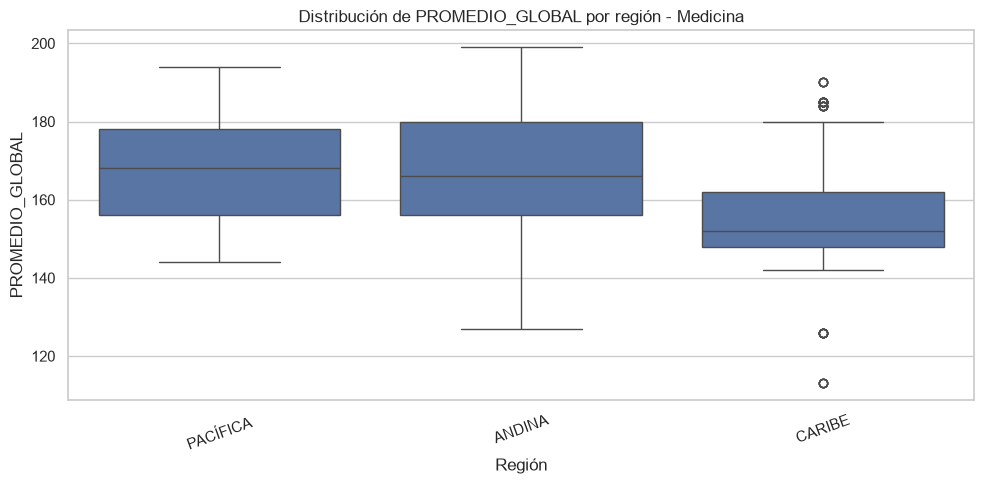

,NOMBRE_REGION,promedio_global_medio,promedio_global_mediano,desviacion,registros
0,PACÍFICA,168.18,168.0,14.97,312
1,ANDINA,167.20,166.0,15.18,1378
2,CARIBE,155.16,152.0,12.60,483


In [17]:
# Comparación por región
region_stats = (
    eda_data
    .groupby('NOMBRE_REGION')
    .agg(
        promedio_global_medio=(TARGET, 'mean'),
        promedio_global_mediano=(TARGET, 'median'),
        desviacion=(TARGET, 'std'),
        registros=(TARGET, 'size')
    )
    .sort_values('promedio_global_medio', ascending=False)
    .reset_index()
)

orden_regiones = region_stats['NOMBRE_REGION']

plt.figure(figsize=(10, 5))
sns.boxplot(data=eda_data, x='NOMBRE_REGION', y=TARGET, order=orden_regiones)
plt.title('Distribución de PROMEDIO_GLOBAL por región - Medicina')
plt.xlabel('Región')
plt.ylabel('PROMEDIO_GLOBAL')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

region_stats.round(2)

**Nota de interpretación:** observá qué regiones tienen mayor promedio, cuánta dispersión interna presentan y si el número de registros es comparable entre regiones.

### 3.4 Comparación por departamento

El análisis departamental permite un nivel más detallado que la región. Ayuda a encontrar territorios con desempeño alto, bajo o muy variable.

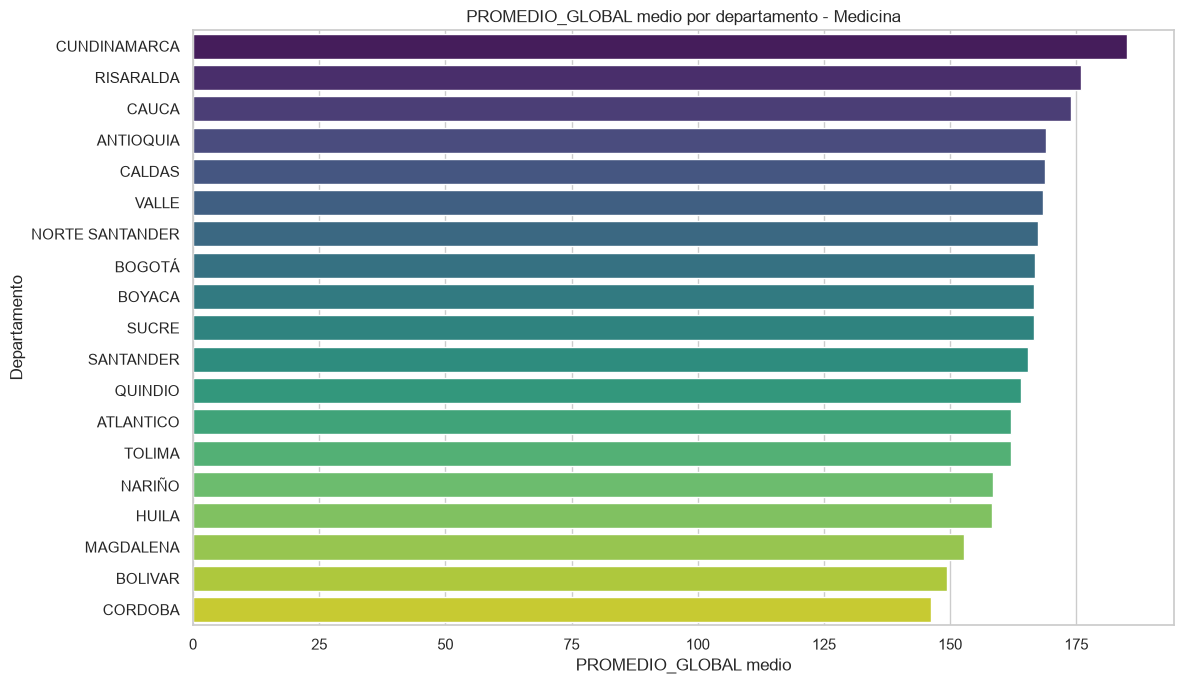

,NOMBRE_DEPARTAMENTO,promedio_global_medio,promedio_global_mediano,registros
0,CUNDINAMARCA,185.11,184.0,36
1,RISARALDA,175.89,175.0,36
2,CAUCA,173.93,171.0,41
3,ANTIOQUIA,168.94,163.0,224
4,CALDAS,168.83,169.0,72
5,VALLE,168.36,167.0,242
6,NORTE SANTANDER,167.47,166.0,36
7,BOGOTÁ,166.88,166.0,581
8,BOYACA,166.62,167.5,72
9,SUCRE,166.56,167.0,36


In [18]:
# Comparación por departamento
departamento_stats = (
    eda_data
    .groupby('NOMBRE_DEPARTAMENTO')
    .agg(
        promedio_global_medio=(TARGET, 'mean'),
        promedio_global_mediano=(TARGET, 'median'),
        registros=(TARGET, 'size')
    )
    .sort_values('promedio_global_medio', ascending=False)
    .reset_index()
)

plt.figure(figsize=(12, 7))
sns.barplot(
    data=departamento_stats,
    y='NOMBRE_DEPARTAMENTO',
    x='promedio_global_medio',
    hue='NOMBRE_DEPARTAMENTO',
    palette='viridis',
    legend=False
)
plt.title('PROMEDIO_GLOBAL medio por departamento - Medicina')
plt.xlabel('PROMEDIO_GLOBAL medio')
plt.ylabel('Departamento')
plt.tight_layout()
plt.show()

departamento_stats.round(2)

**Nota de interpretación:** no compares solo el promedio. Revisá también `registros`, porque departamentos con pocos registros pueden mostrar promedios más inestables.

### 3.5 Instituciones con mejor promedio y suficientes registros

Para evitar rankings débiles, se filtran instituciones con al menos 20 registros en el dataset de Medicina. Esto reduce el riesgo de destacar instituciones con muy pocos datos.

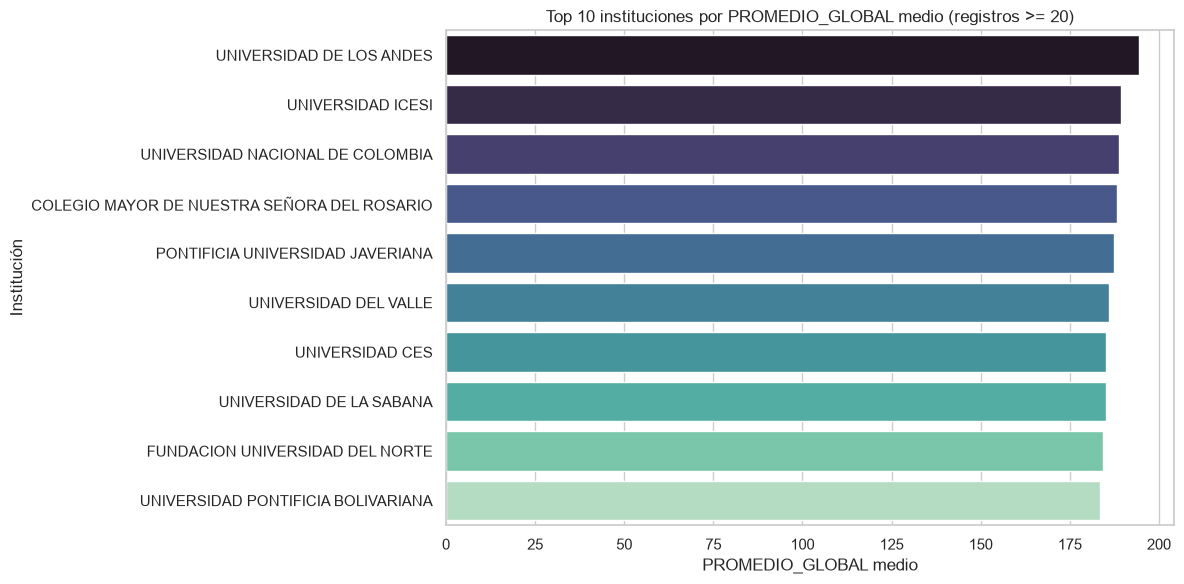

,NOMBRE_INSTITUCION,promedio_global_medio,promedio_global_mediano,registros,cantidad_evaluados_total
24,UNIVERSIDAD DE LOS ANDES,194.50,196.0,36,3949.0
37,UNIVERSIDAD ICESI,189.28,188.0,36,3354.0
42,UNIVERSIDAD NACIONAL DE COLOMBIA,188.67,190.0,36,6529.0
0,COLEGIO MAYOR DE NUESTRA SEÑORA DEL ROSARIO,188.17,187.0,36,8005.0
12,PONTIFICIA UNIVERSIDAD JAVERIANA,187.47,187.5,72,9383.0
35,UNIVERSIDAD DEL VALLE,185.87,190.0,31,2580.0
16,UNIVERSIDAD CES,185.28,187.0,36,4656.0
23,UNIVERSIDAD DE LA SABANA,185.11,184.0,36,5164.0
4,FUNDACION UNIVERSIDAD DEL NORTE,184.36,185.0,36,8037.0
44,UNIVERSIDAD PONTIFICIA BOLIVARIANA,183.39,184.0,36,3319.0


In [19]:
# Top instituciones por PROMEDIO_GLOBAL medio con suficientes registros
MIN_REGISTROS_INSTITUCION = 20

institucion_stats = (
    eda_data
    .groupby('NOMBRE_INSTITUCION')
    .agg(
        promedio_global_medio=(TARGET, 'mean'),
        promedio_global_mediano=(TARGET, 'median'),
        registros=(TARGET, 'size'),
        cantidad_evaluados_total=('CANTIDADEVALUADOS', 'sum')
    )
    .reset_index()
)

instituciones_suficientes = institucion_stats[
    institucion_stats['registros'] >= MIN_REGISTROS_INSTITUCION
].sort_values('promedio_global_medio', ascending=False)

top_instituciones = instituciones_suficientes.head(10)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_instituciones,
    y='NOMBRE_INSTITUCION',
    x='promedio_global_medio',
    hue='NOMBRE_INSTITUCION',
    palette='mako',
    legend=False
)
plt.title(f'Top 10 instituciones por PROMEDIO_GLOBAL medio (registros >= {MIN_REGISTROS_INSTITUCION})')
plt.xlabel('PROMEDIO_GLOBAL medio')
plt.ylabel('Institución')
plt.tight_layout()
plt.show()

top_instituciones.round(2)

**Nota de interpretación:** este ranking es descriptivo, no causal. Una institución con promedio alto no necesariamente mejora por sí sola el desempeño; puede haber factores de selección, contexto, tamaño de cohorte o composición de estudiantes.

### 3.6 Distribución de `CANTIDADEVALUADOS`

La cantidad de evaluados indica el tamaño de cada observación agregada. Valores muy bajos pueden producir promedios menos estables.

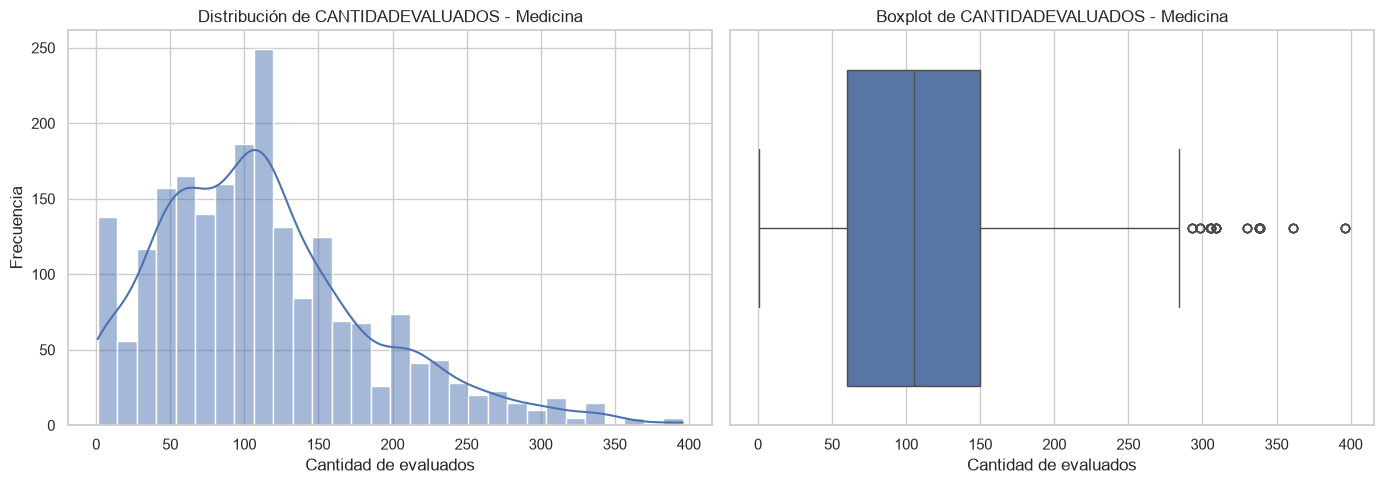

,CANTIDADEVALUADOS
count,2173.000000
mean,112.797515
std,72.855261
min,1.000000
25%,60.000000
50%,105.000000
75%,150.000000
max,396.000000


In [20]:
# Distribución de CANTIDADEVALUADOS
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=eda_data, x='CANTIDADEVALUADOS', bins=30, kde=True, ax=axes[0])
axes[0].set_title('Distribución de CANTIDADEVALUADOS - Medicina')
axes[0].set_xlabel('Cantidad de evaluados')
axes[0].set_ylabel('Frecuencia')

sns.boxplot(data=eda_data, x='CANTIDADEVALUADOS', ax=axes[1])
axes[1].set_title('Boxplot de CANTIDADEVALUADOS - Medicina')
axes[1].set_xlabel('Cantidad de evaluados')

plt.tight_layout()
plt.show()

eda_data['CANTIDADEVALUADOS'].describe().to_frame('CANTIDADEVALUADOS')

**Nota de interpretación:** si hay observaciones con muy pocos evaluados, conviene analizarlas con cautela. En etapas posteriores se puede evaluar un umbral mínimo o usar ponderaciones.

### 3.7 Detección de outliers en `PROMEDIO_GLOBAL` por IQR

El método IQR marca como potenciales outliers los valores por debajo de `Q1 - 1.5 * IQR` o por encima de `Q3 + 1.5 * IQR`.

Q1: 152.00
Q3: 175.00
IQR: 23.00
Límite inferior: 117.50
Límite superior: 209.50
Outliers detectados: 5 (0.23%)


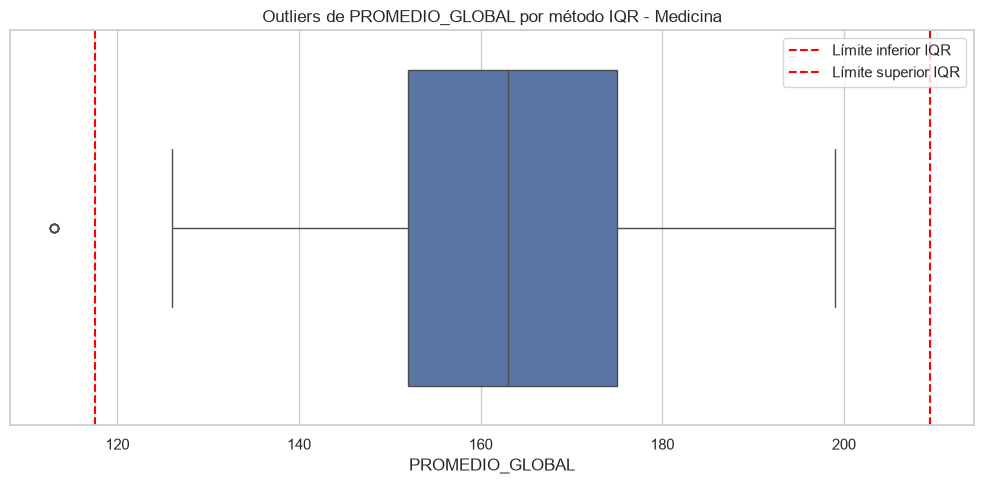

,AÑO,NOMBRE_REGION,NOMBRE_DEPARTAMENTO,NOMBRE_INSTITUCION,NOMBRE_PROGRAMA_ACAD,NOMBRE_PRUEBA,CANTIDADEVALUADOS,PROMEDIO_GLOBAL
38480,2021,CARIBE,BOLIVAR,UNIVERSIDAD DEL SINÚ ELIAS BECHARA ZAINUM - UN...,MEDICINA,RAZONAMIENTO CUANTITATIVO,1.0,113.0
38488,2021,CARIBE,BOLIVAR,UNIVERSIDAD DEL SINÚ ELIAS BECHARA ZAINUM - UN...,MEDICINA,LECTURA CRÍTICA,1.0,113.0
38496,2021,CARIBE,BOLIVAR,UNIVERSIDAD DEL SINÚ ELIAS BECHARA ZAINUM - UN...,MEDICINA,INGLÉS,1.0,113.0
38514,2021,CARIBE,BOLIVAR,UNIVERSIDAD DEL SINÚ ELIAS BECHARA ZAINUM - UN...,MEDICINA,COMPETENCIAS CIUDADANAS,1.0,113.0
38555,2021,CARIBE,BOLIVAR,UNIVERSIDAD DEL SINÚ ELIAS BECHARA ZAINUM - UN...,MEDICINA,COMUNICACIÓN ESCRITA,1.0,113.0


In [21]:
# Detección de outliers de PROMEDIO_GLOBAL usando IQR
q1 = eda_data[TARGET].quantile(0.25)
q3 = eda_data[TARGET].quantile(0.75)
iqr = q3 - q1
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

outliers_promedio_global = eda_data[
    (eda_data[TARGET] < limite_inferior) |
    (eda_data[TARGET] > limite_superior)
].copy()

print(f'Q1: {q1:.2f}')
print(f'Q3: {q3:.2f}')
print(f'IQR: {iqr:.2f}')
print(f'Límite inferior: {limite_inferior:.2f}')
print(f'Límite superior: {limite_superior:.2f}')
print(f'Outliers detectados: {len(outliers_promedio_global)} ({len(outliers_promedio_global) / len(eda_data) * 100:.2f}%)')

plt.figure(figsize=(10, 5))
sns.boxplot(data=eda_data, x=TARGET)
plt.axvline(limite_inferior, color='red', linestyle='--', label='Límite inferior IQR')
plt.axvline(limite_superior, color='red', linestyle='--', label='Límite superior IQR')
plt.title('Outliers de PROMEDIO_GLOBAL por método IQR - Medicina')
plt.xlabel('PROMEDIO_GLOBAL')
plt.legend()
plt.tight_layout()
plt.show()

outliers_promedio_global[
    ['AÑO', 'NOMBRE_REGION', 'NOMBRE_DEPARTAMENTO', 'NOMBRE_INSTITUCION',
     'NOMBRE_PROGRAMA_ACAD', 'NOMBRE_PRUEBA', 'CANTIDADEVALUADOS', TARGET]
].sort_values(TARGET).head(10)

**Nota de interpretación:** un outlier no es automáticamente un error. Puede representar un programa, año o prueba con desempeño excepcionalmente bajo/alto. Antes de eliminarlo, debe revisarse el contexto.

### 3.8 Relación entre `CANTIDADEVALUADOS` y `PROMEDIO_GLOBAL`

Esta gráfica revisa si el tamaño del grupo evaluado se asocia con el desempeño global.

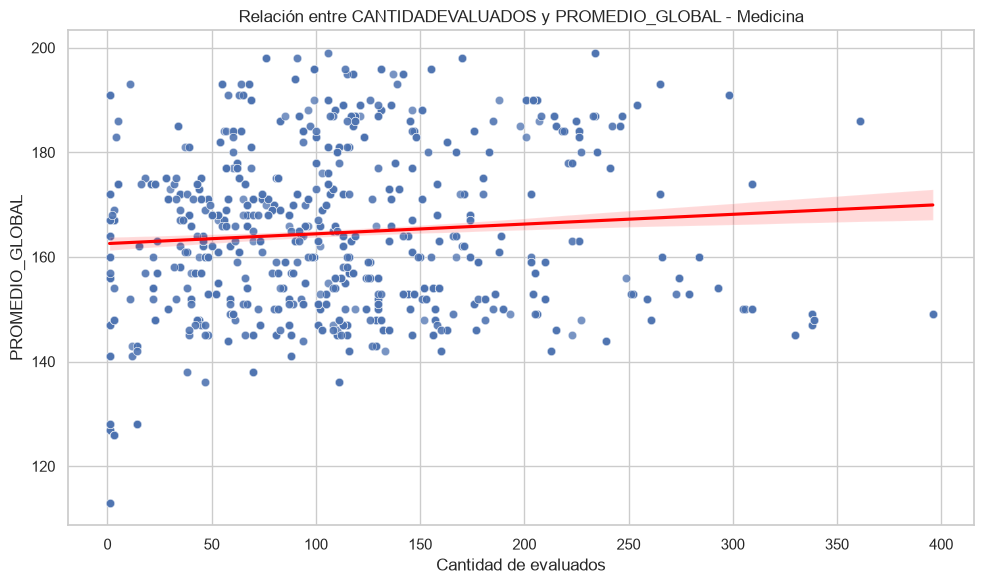

Correlación Pearson: 0.088


In [22]:
# Relación entre CANTIDADEVALUADOS y PROMEDIO_GLOBAL
correlacion_evaluados_promedio = eda_data[['CANTIDADEVALUADOS', TARGET]].corr().iloc[0, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=eda_data,
    x='CANTIDADEVALUADOS',
    y=TARGET,
    alpha=0.5
)
sns.regplot(
    data=eda_data,
    x='CANTIDADEVALUADOS',
    y=TARGET,
    scatter=False,
    color='red'
)
plt.title('Relación entre CANTIDADEVALUADOS y PROMEDIO_GLOBAL - Medicina')
plt.xlabel('Cantidad de evaluados')
plt.ylabel('PROMEDIO_GLOBAL')
plt.tight_layout()
plt.show()

print(f'Correlación Pearson: {correlacion_evaluados_promedio:.3f}')

**Nota de interpretación:** una correlación cercana a cero indica relación lineal débil. Si la relación es débil, `CANTIDADEVALUADOS` puede seguir siendo útil como variable de contexto, pero no explica por sí sola el desempeño global.

## 4. Ingeniería de Características

Esta etapa transforma el dataset filtrado de Medicina en variables históricas útiles para modelado. El objetivo es construir señales de tendencia, variación y estabilidad **sin usar información futura**.

Antes de crear variables temporales, agregamos los registros a nivel anual por institución y programa académico. Esto es necesario porque el dataset original contiene varias filas por programa-año, una por prueba o módulo (`NOMBRE_PRUEBA`).


### 4.1 Dataset anual por institución y programa

El nuevo dataset `medicina_anual` queda en el nivel:

```text
AÑO + institución + programa académico
```

Se usan identificadores y nombres para mantener trazabilidad. La agregación usa:

- `PROMEDIO_GLOBAL` promedio como `promedio_global_anual`;
- `PROMEDIO_PRUEBA` promedio como variable descriptiva, no como predictor inicial conservador;
- `CANTIDADEVALUADOS` media y máximo por pruebas, evitando sumar para no duplicar estudiantes entre módulos;
- cantidad de pruebas distintas como `cantidad_pruebas`.

La decisión sobre `CANTIDADEVALUADOS` es conservadora: como una misma cohorte aparece repetida por diferentes pruebas, sumar podría inflar artificialmente el tamaño real del grupo. Por eso se conservan media y máximo para análisis posterior.


In [23]:
# Construir dataset anual por institución y programa
nivel_agregacion = [
    'AÑO',
    'ID_REGION', 'NOMBRE_REGION',
    'ID_DEPARTAMENTO', 'NOMBRE_DEPARTAMENTO',
    'ID_MUNICIPIO', 'NOMBRE_MUNICIPIO',
    'ID_INSTITUCION', 'NOMBRE_INSTITUCION',
    'ID_NBC', 'NBC',
    'ID_PROGRAMA_ACAD', 'NOMBRE_PROGRAMA_ACAD'
]

medicina_anual = (
    eda_data
    .groupby(nivel_agregacion, dropna=False)
    .agg(
        promedio_global_anual=(TARGET, 'mean'),
        promedio_prueba_media=('PROMEDIO_PRUEBA', 'mean'),
        cantidad_evaluados_media_pruebas=('CANTIDADEVALUADOS', 'mean'),
        cantidad_evaluados_max_pruebas=('CANTIDADEVALUADOS', 'max'),
        cantidad_pruebas=('NOMBRE_PRUEBA', 'nunique'),
        registros_modulo=('NOMBRE_PRUEBA', 'size')
    )
    .reset_index()
    .sort_values(['ID_INSTITUCION', 'ID_PROGRAMA_ACAD', 'AÑO'])
    .reset_index(drop=True)
)

print(f'Filas en medicina_anual: {medicina_anual.shape[0]}')
print(f'Columnas en medicina_anual: {medicina_anual.shape[1]}')
medicina_anual.head()


Filas en medicina_anual: 306
Columnas en medicina_anual: 19


,AÑO,ID_REGION,NOMBRE_REGION,ID_DEPARTAMENTO,NOMBRE_DEPARTAMENTO,ID_MUNICIPIO,NOMBRE_MUNICIPIO,ID_INSTITUCION,NOMBRE_INSTITUCION,ID_NBC,NBC,ID_PROGRAMA_ACAD,NOMBRE_PROGRAMA_ACAD,promedio_global_anual,promedio_prueba_media,cantidad_evaluados_media_pruebas,cantidad_evaluados_max_pruebas,cantidad_pruebas,registros_modulo
0,2023,2.0,ANDINA,1.0,ANTIOQUIA,1.0,MEDELLÍN,8894.0,UNIVERSIDAD DE ANTIOQUIA,45.0,MEDICINA,6054.0,MEDICINA,156.0,146.875000,1.000000,1.0,8,8
1,2020,2.0,ANDINA,1.0,ANTIOQUIA,1.0,MEDELLÍN,8894.0,UNIVERSIDAD DE ANTIOQUIA,45.0,MEDICINA,6217.0,MEDICINA,187.0,186.800000,234.000000,234.0,5,5
2,2021,2.0,ANDINA,1.0,ANTIOQUIA,1.0,MEDELLÍN,8894.0,UNIVERSIDAD DE ANTIOQUIA,45.0,MEDICINA,6217.0,MEDICINA,183.0,181.857143,218.857143,226.0,7,7
3,2022,2.0,ANDINA,1.0,ANTIOQUIA,1.0,MEDELLÍN,8894.0,UNIVERSIDAD DE ANTIOQUIA,45.0,MEDICINA,6217.0,MEDICINA,178.0,178.375000,222.250000,223.0,8,8
4,2023,2.0,ANDINA,1.0,ANTIOQUIA,1.0,MEDELLÍN,8894.0,UNIVERSIDAD DE ANTIOQUIA,45.0,MEDICINA,6217.0,MEDICINA,182.0,182.000000,137.125000,163.0,8,8


### 4.2 Variables históricas sin fuga de información

A partir de `medicina_anual` se crea `medicina_features`. Las variables se calculan dentro de cada combinación institución-programa y respetan el orden temporal.

Variables creadas:

| Variable | Significado | Utilidad |
|---|---|---|
| `promedio_global_anterior` | Promedio global del año anterior | Captura desempeño histórico inmediato |
| `variacion_anual` | Diferencia contra el año anterior | Mide mejora o caída absoluta |
| `variacion_porcentual` | Cambio porcentual contra el año anterior | Normaliza la variación relativa |
| `promedio_movil_2_anios` | Promedio de hasta dos años previos | Resume tendencia reciente |
| `desviacion_historica_2_anios` | Desviación de hasta dos años previos | Mide estabilidad reciente |
| `crecimiento_acumulado_desde_inicio` | Cambio frente al primer año observado del programa | Resume evolución acumulada |
| `mejora_vs_anio_anterior` | Indicador 1/0 de mejora anual | Señal interpretable de crecimiento |
| `disminuye_vs_anio_anterior` | Indicador 1/0 de caída anual | Señal interpretable de deterioro |
| `anios_historicos_disponibles` | Cantidad de años previos observados | Indica cuánta historia tiene el registro |

#### Salvaguarda anti-leakage

Las variables móviles y de desviación usan `shift(1)` antes del cálculo. Eso garantiza que el año actual no se use para construir sus propias variables históricas.


In [24]:
# Crear variables históricas sin usar información futura
llaves_programa = ['ID_INSTITUCION', 'ID_PROGRAMA_ACAD']

medicina_features = (
    medicina_anual
    .sort_values(llaves_programa + ['AÑO'])
    .reset_index(drop=True)
    .copy()
)

grupo_programa = medicina_features.groupby(llaves_programa, sort=False)

medicina_features['promedio_global_anterior'] = grupo_programa['promedio_global_anual'].shift(1)
medicina_features['variacion_anual'] = (
    medicina_features['promedio_global_anual'] - medicina_features['promedio_global_anterior']
)
medicina_features['variacion_porcentual'] = np.where(
    medicina_features['promedio_global_anterior'].notna() &
    medicina_features['promedio_global_anterior'].ne(0),
    medicina_features['variacion_anual'] / medicina_features['promedio_global_anterior'] * 100,
    np.nan
)

medicina_features['promedio_movil_2_anios'] = grupo_programa['promedio_global_anual'].transform(
    lambda serie: serie.shift(1).rolling(window=2, min_periods=1).mean()
)
medicina_features['desviacion_historica_2_anios'] = grupo_programa['promedio_global_anual'].transform(
    lambda serie: serie.shift(1).rolling(window=2, min_periods=2).std()
)

primer_promedio_programa = grupo_programa['promedio_global_anual'].transform('first')
medicina_features['crecimiento_acumulado_desde_inicio'] = (
    medicina_features['promedio_global_anual'] - primer_promedio_programa
)

medicina_features['mejora_vs_anio_anterior'] = np.where(
    medicina_features['promedio_global_anterior'].notna() &
    (medicina_features['promedio_global_anual'] > medicina_features['promedio_global_anterior']),
    1,
    0
)
medicina_features['disminuye_vs_anio_anterior'] = np.where(
    medicina_features['promedio_global_anterior'].notna() &
    (medicina_features['promedio_global_anual'] < medicina_features['promedio_global_anterior']),
    1,
    0
)
medicina_features['anios_historicos_disponibles'] = grupo_programa.cumcount()

print(f'Filas en medicina_features: {medicina_features.shape[0]}')
print(f'Columnas en medicina_features: {medicina_features.shape[1]}')
medicina_features.head()


Filas en medicina_features: 306
Columnas en medicina_features: 28


,AÑO,ID_REGION,NOMBRE_REGION,ID_DEPARTAMENTO,NOMBRE_DEPARTAMENTO,ID_MUNICIPIO,NOMBRE_MUNICIPIO,ID_INSTITUCION,NOMBRE_INSTITUCION,ID_NBC,NBC,ID_PROGRAMA_ACAD,NOMBRE_PROGRAMA_ACAD,promedio_global_anual,promedio_prueba_media,cantidad_evaluados_media_pruebas,cantidad_evaluados_max_pruebas,cantidad_pruebas,registros_modulo,promedio_global_anterior,variacion_anual,variacion_porcentual,promedio_movil_2_anios,desviacion_historica_2_anios,crecimiento_acumulado_desde_inicio,mejora_vs_anio_anterior,disminuye_vs_anio_anterior,anios_historicos_disponibles
0,2023,2.0,ANDINA,1.0,ANTIOQUIA,1.0,MEDELLÍN,8894.0,UNIVERSIDAD DE ANTIOQUIA,45.0,MEDICINA,6054.0,MEDICINA,156.0,146.875000,1.000000,1.0,8,8,NaN,NaN,NaN,NaN,NaN,0.0,0,0,0
1,2020,2.0,ANDINA,1.0,ANTIOQUIA,1.0,MEDELLÍN,8894.0,UNIVERSIDAD DE ANTIOQUIA,45.0,MEDICINA,6217.0,MEDICINA,187.0,186.800000,234.000000,234.0,5,5,NaN,NaN,NaN,NaN,NaN,0.0,0,0,0
2,2021,2.0,ANDINA,1.0,ANTIOQUIA,1.0,MEDELLÍN,8894.0,UNIVERSIDAD DE ANTIOQUIA,45.0,MEDICINA,6217.0,MEDICINA,183.0,181.857143,218.857143,226.0,7,7,187.0,-4.0,-2.139037,187.0,NaN,-4.0,0,1,1
3,2022,2.0,ANDINA,1.0,ANTIOQUIA,1.0,MEDELLÍN,8894.0,UNIVERSIDAD DE ANTIOQUIA,45.0,MEDICINA,6217.0,MEDICINA,178.0,178.375000,222.250000,223.0,8,8,183.0,-5.0,-2.732240,185.0,2.828427,-9.0,0,1,2
4,2023,2.0,ANDINA,1.0,ANTIOQUIA,1.0,MEDELLÍN,8894.0,UNIVERSIDAD DE ANTIOQUIA,45.0,MEDICINA,6217.0,MEDICINA,182.0,182.000000,137.125000,163.0,8,8,178.0,4.0,2.247191,180.5,3.535534,-5.0,1,0,3


### 4.3 Revisión de variables generadas

Esta revisión permite confirmar que las nuevas columnas tienen sentido temporal: las primeras observaciones de cada programa no deben tener año anterior, variación anual ni promedio móvil histórico.


In [25]:
# Revisar columnas creadas y valores faltantes esperados
columnas_features = [
    'promedio_global_anterior',
    'variacion_anual',
    'variacion_porcentual',
    'promedio_movil_2_anios',
    'desviacion_historica_2_anios',
    'crecimiento_acumulado_desde_inicio',
    'mejora_vs_anio_anterior',
    'disminuye_vs_anio_anterior',
    'anios_historicos_disponibles'
]

faltantes_features = medicina_features[columnas_features].isna().sum().to_frame('faltantes')
faltantes_features['porcentaje'] = (
    faltantes_features['faltantes'] / len(medicina_features) * 100
).round(2)

faltantes_features


,faltantes,porcentaje
promedio_global_anterior,70,22.88
variacion_anual,70,22.88
variacion_porcentual,70,22.88
promedio_movil_2_anios,70,22.88
desviacion_historica_2_anios,134,43.79
crecimiento_acumulado_desde_inicio,0,0.00
mejora_vs_anio_anterior,0,0.00
disminuye_vs_anio_anterior,0,0.00
anios_historicos_disponibles,0,0.00


In [26]:
# Muestra de filas con variables históricas
columnas_muestra_features = [
    'AÑO', 'ID_INSTITUCION', 'NOMBRE_INSTITUCION', 'ID_PROGRAMA_ACAD', 'NOMBRE_PROGRAMA_ACAD',
    'promedio_global_anual', 'promedio_global_anterior',
    'variacion_anual', 'variacion_porcentual',
    'promedio_movil_2_anios', 'desviacion_historica_2_anios',
    'crecimiento_acumulado_desde_inicio',
    'mejora_vs_anio_anterior', 'disminuye_vs_anio_anterior',
    'anios_historicos_disponibles'
]

medicina_features[columnas_muestra_features].head(15)


,AÑO,ID_INSTITUCION,NOMBRE_INSTITUCION,ID_PROGRAMA_ACAD,NOMBRE_PROGRAMA_ACAD,promedio_global_anual,promedio_global_anterior,variacion_anual,variacion_porcentual,promedio_movil_2_anios,desviacion_historica_2_anios,crecimiento_acumulado_desde_inicio,mejora_vs_anio_anterior,disminuye_vs_anio_anterior,anios_historicos_disponibles
0,2023,8894.0,UNIVERSIDAD DE ANTIOQUIA,6054.0,MEDICINA,156.0,NaN,NaN,NaN,NaN,NaN,0.0,0,0,0
1,2020,8894.0,UNIVERSIDAD DE ANTIOQUIA,6217.0,MEDICINA,187.0,NaN,NaN,NaN,NaN,NaN,0.0,0,0,0
2,2021,8894.0,UNIVERSIDAD DE ANTIOQUIA,6217.0,MEDICINA,183.0,187.0,-4.0,-2.139037,187.0,NaN,-4.0,0,1,1
3,2022,8894.0,UNIVERSIDAD DE ANTIOQUIA,6217.0,MEDICINA,178.0,183.0,-5.0,-2.732240,185.0,2.828427,-9.0,0,1,2
4,2023,8894.0,UNIVERSIDAD DE ANTIOQUIA,6217.0,MEDICINA,182.0,178.0,4.0,2.247191,180.5,3.535534,-5.0,1,0,3
5,2024,8894.0,UNIVERSIDAD DE ANTIOQUIA,6217.0,MEDICINA,186.0,182.0,4.0,2.197802,180.0,2.828427,-1.0,1,0,4
6,2020,8903.0,CORPORACION UNIVERSITARIA REMINGTON,2329.0,MEDICINA,155.0,NaN,NaN,NaN,NaN,NaN,0.0,0,0,0
7,2021,8903.0,CORPORACION UNIVERSITARIA REMINGTON,2329.0,MEDICINA,155.0,155.0,0.0,0.000000,155.0,NaN,0.0,0,0,1
8,2022,8903.0,CORPORACION UNIVERSITARIA REMINGTON,2329.0,MEDICINA,151.0,155.0,-4.0,-2.580645,155.0,0.000000,-4.0,0,1,2
9,2023,8903.0,CORPORACION UNIVERSITARIA REMINGTON,2329.0,MEDICINA,145.0,151.0,-6.0,-3.973510,153.0,2.828427,-10.0,0,1,3


### 4.4 Validaciones de ingeniería de características

Estas pruebas verifican estructura, columnas y reglas temporales mínimas. En especial, aseguran que la primera observación de cada institución-programa no tenga variables dependientes del año anterior.


In [27]:
# Validaciones de ingeniería de características
primeras_observaciones = medicina_features[
    medicina_features['anios_historicos_disponibles'].eq(0)
]

assert medicina_anual.shape[0] > 0
assert medicina_features.shape[0] == medicina_anual.shape[0]
assert set(columnas_features).issubset(medicina_features.columns)

assert primeras_observaciones['promedio_global_anterior'].isna().all()
assert primeras_observaciones['variacion_anual'].isna().all()
assert primeras_observaciones['variacion_porcentual'].isna().all()
assert primeras_observaciones['promedio_movil_2_anios'].isna().all()
assert primeras_observaciones['desviacion_historica_2_anios'].isna().all()
assert (primeras_observaciones['crecimiento_acumulado_desde_inicio'].abs() < 1e-9).all()
assert (primeras_observaciones['mejora_vs_anio_anterior'] == 0).all()
assert (primeras_observaciones['disminuye_vs_anio_anterior'] == 0).all()

print('FEATURE_ENGINEERING_VALIDATION_OK')
print(f'Programas únicos con historia: {medicina_features[llaves_programa].drop_duplicates().shape[0]}')
print(f'Primeras observaciones validadas: {primeras_observaciones.shape[0]}')
print(f'Filas con al menos un año histórico: {(medicina_features["anios_historicos_disponibles"] > 0).sum()}')


FEATURE_ENGINEERING_VALIDATION_OK
Programas únicos con historia: 70
Primeras observaciones validadas: 70
Filas con al menos un año histórico: 236


## 5. Entrenamiento y comparación inicial de modelos

Esta etapa construye un **benchmark limpio pre-SHAP** de modelos de regresión para predecir `promedio_global_anual` usando `medicina_features`.

La corrección metodológica principal es excluir del modelado las variables operativas del mismo periodo:

- `cantidad_evaluados_media_pruebas`;
- `cantidad_evaluados_max_pruebas`.

Estas variables se mantienen en EDA e ingeniería de características como contexto descriptivo, pero no entran al modelo porque podrían no conocerse al momento real de hacer una predicción anticipada.

El benchmark respeta una partición temporal:

```text
Entrenamiento: AÑO <= 2022
Validación:    AÑO == 2023
Prueba:        AÑO == 2024
```

La selección inicial se hace por menor **MAE en validación**.

### 5.1 Definición de variables predictoras y control de fuga de información

Se usa `medicina_features` como fuente y `promedio_global_anual` como variable objetivo.

Para evitar fuga de información y mantener un escenario predictivo más realista antes de SHAP, **no se usan** variables calculadas con el resultado del mismo año ni variables operativas que podrían conocerse solo después del periodo evaluado:

- `promedio_global_anual` como predictor;
- `promedio_prueba_media`;
- `variacion_anual`;
- `variacion_porcentual`;
- `crecimiento_acumulado_desde_inicio`;
- `mejora_vs_anio_anterior`;
- `disminuye_vs_anio_anterior`;
- `cantidad_evaluados_media_pruebas`;
- `cantidad_evaluados_max_pruebas`.

Sí se usan variables históricas calculadas con `shift(1)` y metadatos estables de ubicación, institución y programa.

In [28]:
# Preparar datos para entrenamiento evitando fuga de información
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor

TARGET_MODEL = 'promedio_global_anual'

variables_operativas_excluidas_modelo = [
    'cantidad_evaluados_media_pruebas',
    'cantidad_evaluados_max_pruebas',
]

columnas_no_permitidas_modelo = [
    TARGET_MODEL,
    'promedio_prueba_media',
    'variacion_anual',
    'variacion_porcentual',
    'crecimiento_acumulado_desde_inicio',
    'mejora_vs_anio_anterior',
    'disminuye_vs_anio_anterior',
] + variables_operativas_excluidas_modelo

features_numericas = [
    'AÑO',
    'promedio_global_anterior',
    'promedio_movil_2_anios',
    'desviacion_historica_2_anios',
    'anios_historicos_disponibles',
]

features_categoricas = [
    'NOMBRE_REGION',
    'NOMBRE_DEPARTAMENTO',
    'NOMBRE_MUNICIPIO',
    'NOMBRE_INSTITUCION',
    'NOMBRE_PROGRAMA_ACAD',
]

features_modelo = features_numericas + features_categoricas

columnas_faltantes_modelo = [c for c in features_modelo + [TARGET_MODEL] if c not in medicina_features.columns]
assert not columnas_faltantes_modelo, f'Columnas faltantes para modelado: {columnas_faltantes_modelo}'
assert not set(features_modelo).intersection(columnas_no_permitidas_modelo)

modeling_data = medicina_features[features_modelo + [TARGET_MODEL]].dropna(subset=[TARGET_MODEL]).copy()

print('Modelo limpio pre-SHAP: sin variables cantidad_evaluados_* como predictores')
print(f'Filas disponibles para modelado: {modeling_data.shape[0]}')
print(f'Columnas predictoras: {len(features_modelo)}')
print('Features numéricas:', features_numericas)
print('Features categóricas:', features_categoricas)
print('Variables operativas excluidas:', variables_operativas_excluidas_modelo)

Modelo limpio pre-SHAP: sin variables cantidad_evaluados_* como predictores
Filas disponibles para modelado: 306
Columnas predictoras: 10
Features numéricas: ['AÑO', 'promedio_global_anterior', 'promedio_movil_2_anios', 'desviacion_historica_2_anios', 'anios_historicos_disponibles']
Features categóricas: ['NOMBRE_REGION', 'NOMBRE_DEPARTAMENTO', 'NOMBRE_MUNICIPIO', 'NOMBRE_INSTITUCION', 'NOMBRE_PROGRAMA_ACAD']
Variables operativas excluidas: ['cantidad_evaluados_media_pruebas', 'cantidad_evaluados_max_pruebas']


### 5.2 Partición temporal

Se separa el dataset por año para simular un escenario realista: entrenar con años pasados, validar con un año posterior y probar con el último año disponible.

Esto evita mezclar observaciones futuras en entrenamiento.

In [29]:
# Partición temporal: entrenamiento <= 2022, validación 2023, prueba 2024
train_data = modeling_data[modeling_data['AÑO'] <= 2022].copy()
valid_data = modeling_data[modeling_data['AÑO'] == 2023].copy()
test_data = modeling_data[modeling_data['AÑO'] == 2024].copy()

split_strategy = 'temporal_preferido_train_2020_2022_valid_2023_test_2024'

if train_data.empty or valid_data.empty:
    split_strategy = 'fallback_train_hasta_2023_test_2024_sin_validacion_independiente'
    train_data = modeling_data[modeling_data['AÑO'] <= 2023].copy()
    valid_data = modeling_data[modeling_data['AÑO'] == 2024].copy()
    test_data = pd.DataFrame(columns=modeling_data.columns)

X_train = train_data[features_modelo]
y_train = train_data[TARGET_MODEL]

X_valid = valid_data[features_modelo]
y_valid = valid_data[TARGET_MODEL]

X_test = test_data[features_modelo]
y_test = test_data[TARGET_MODEL]

split_sizes = {
    'train': int(len(train_data)),
    'validation': int(len(valid_data)),
    'test': int(len(test_data)),
}

print('Estrategia de partición:', split_strategy)
print(split_sizes)
print('Años entrenamiento:', sorted(train_data['AÑO'].dropna().unique().tolist()))
print('Años validación:', sorted(valid_data['AÑO'].dropna().unique().tolist()))
print('Años prueba:', sorted(test_data['AÑO'].dropna().unique().tolist()))

Estrategia de partición: temporal_preferido_train_2020_2022_valid_2023_test_2024
{'train': 175, 'validation': 68, 'test': 63}
Años entrenamiento: [2020, 2021, 2022]
Años validación: [2023]
Años prueba: [2024]


### 5.3 Preprocesamiento con `ColumnTransformer`

El preprocesamiento separa variables numéricas y categóricas:

- numéricas: imputación por mediana y escalado;
- categóricas: imputación por valor más frecuente y codificación One-Hot.

Este diseño permite entrenar modelos de scikit-learn con un pipeline reproducible.

In [30]:
# Preprocesamiento para variables numéricas y categóricas
def crear_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=False)

transformador_numerico = Pipeline(steps=[
    ('imputador', SimpleImputer(strategy='median')),
    ('escalador', StandardScaler()),
])

transformador_categorico = Pipeline(steps=[
    ('imputador', SimpleImputer(strategy='most_frequent')),
    ('one_hot', crear_one_hot_encoder()),
])

preprocesamiento = ColumnTransformer(
    transformers=[
        ('numericas', transformador_numerico, features_numericas),
        ('categoricas', transformador_categorico, features_categoricas),
    ],
    remainder='drop'
)

preprocesamiento

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numericas', ...), ('categoricas', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``

### 5.4 Entrenamiento y comparación de modelos

Se comparan cuatro alternativas iniciales:

1. **Baseline**: predice siempre la media del entrenamiento.
2. **Ridge Regression**: modelo lineal regularizado.
3. **Decision Tree Regressor**: modelo no lineal simple e interpretable.
4. **Random Forest Regressor**: ensamble de árboles para mejorar estabilidad.

La métrica principal para seleccionar el mejor modelo inicial es **MAE en validación**.

In [31]:
# Entrenar modelos y evaluar con MAE, RMSE y R2
modelos = {
    'Baseline media': DummyRegressor(strategy='mean'),
    'Ridge Regression': Ridge(alpha=1.0),
    'Decision Tree': DecisionTreeRegressor(
        max_depth=4,
        min_samples_leaf=5,
        random_state=42,
    ),
    'Random Forest': RandomForestRegressor(
        n_estimators=200,
        max_depth=6,
        min_samples_leaf=4,
        random_state=42,
        n_jobs=-1,
    ),
}

def evaluar_regresion(nombre_modelo, pipeline, X, y, split):
    if len(y) == 0:
        return {
            'modelo': nombre_modelo,
            'split': split,
            'MAE': np.nan,
            'RMSE': np.nan,
            'R2': np.nan,
            'n': 0,
        }
    predicciones = pipeline.predict(X)
    return {
        'modelo': nombre_modelo,
        'split': split,
        'MAE': mean_absolute_error(y, predicciones),
        'RMSE': np.sqrt(mean_squared_error(y, predicciones)),
        'R2': r2_score(y, predicciones),
        'n': int(len(y)),
    }

pipelines_entrenados = {}
filas_resultados = []

for nombre_modelo, estimador in modelos.items():
    pipeline = Pipeline(steps=[
        ('preprocesamiento', preprocesamiento),
        ('modelo', estimador),
    ])
    pipeline.fit(X_train, y_train)
    pipelines_entrenados[nombre_modelo] = pipeline

    filas_resultados.append(evaluar_regresion(nombre_modelo, pipeline, X_train, y_train, 'entrenamiento'))
    filas_resultados.append(evaluar_regresion(nombre_modelo, pipeline, X_valid, y_valid, 'validacion'))
    filas_resultados.append(evaluar_regresion(nombre_modelo, pipeline, X_test, y_test, 'test'))

resultados_modelos = pd.DataFrame(filas_resultados)
for columna in ['MAE', 'RMSE', 'R2']:
    resultados_modelos[columna] = resultados_modelos[columna].round(3)

resultados_modelos

,modelo,split,MAE,RMSE,R2,n
0,Baseline media,entrenamiento,13.197,15.863,0.000,175
1,Baseline media,validacion,13.013,15.475,-0.015,68
2,Baseline media,test,12.656,15.228,-0.009,63
3,Ridge Regression,entrenamiento,4.328,6.370,0.839,175
4,Ridge Regression,validacion,5.948,7.794,0.743,68
5,Ridge Regression,test,7.553,9.104,0.639,63
6,Decision Tree,entrenamiento,6.620,9.568,0.636,175
7,Decision Tree,validacion,6.092,7.956,0.732,68
8,Decision Tree,test,6.035,7.991,0.722,63
9,Random Forest,entrenamiento,6.114,9.164,0.666,175


In [32]:
# Seleccionar mejor modelo por MAE de validación
resultados_validacion = resultados_modelos[
    resultados_modelos['split'].eq('validacion') & resultados_modelos['MAE'].notna()
].copy()

mejor_modelo_nombre = resultados_validacion.sort_values('MAE').iloc[0]['modelo']
mejor_modelo = pipelines_entrenados[mejor_modelo_nombre]

mejor_validacion = resultados_modelos[
    resultados_modelos['modelo'].eq(mejor_modelo_nombre) & resultados_modelos['split'].eq('validacion')
].iloc[0]

mejor_test = resultados_modelos[
    resultados_modelos['modelo'].eq(mejor_modelo_nombre) & resultados_modelos['split'].eq('test')
]

print(f'Mejor modelo inicial según MAE de validación: {mejor_modelo_nombre}')
print('Métricas en validación:')
print(mejor_validacion[['MAE', 'RMSE', 'R2', 'n']])

if not mejor_test.empty and pd.notna(mejor_test.iloc[0]['MAE']):
    print()
    print('Métricas en test:')
    print(mejor_test.iloc[0][['MAE', 'RMSE', 'R2', 'n']])

Mejor modelo inicial según MAE de validación: Random Forest
Métricas en validación:
MAE     5.509
RMSE    7.305
R2      0.774
n          68
Name: 10, dtype: object

Métricas en test:
MAE     5.486
RMSE    6.985
R2      0.788
n          63
Name: 11, dtype: object


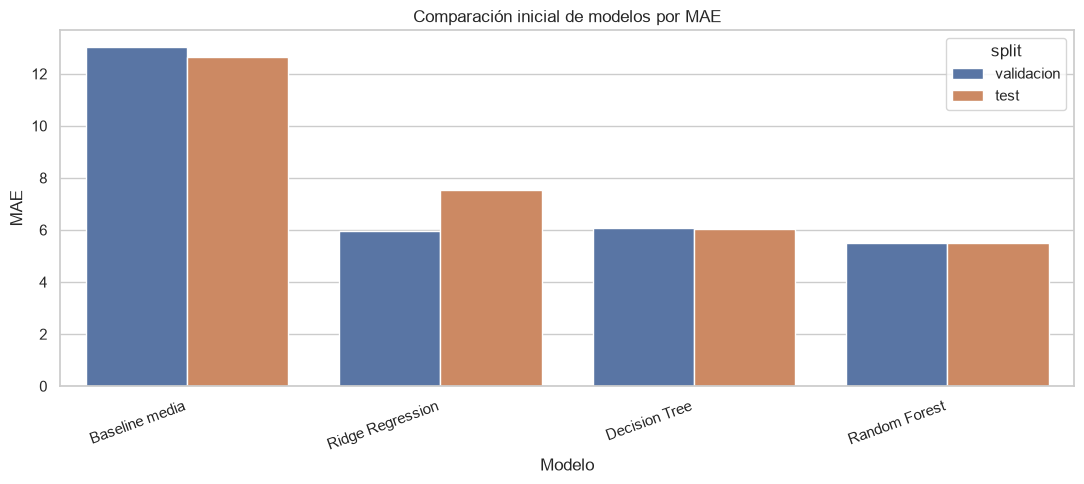

,modelo,split,MAE,RMSE,R2,n
11,Random Forest,test,5.486,6.985,0.788,63
8,Decision Tree,test,6.035,7.991,0.722,63
5,Ridge Regression,test,7.553,9.104,0.639,63
2,Baseline media,test,12.656,15.228,-0.009,63
10,Random Forest,validacion,5.509,7.305,0.774,68
4,Ridge Regression,validacion,5.948,7.794,0.743,68
7,Decision Tree,validacion,6.092,7.956,0.732,68
1,Baseline media,validacion,13.013,15.475,-0.015,68


In [33]:
# Gráfico comparativo de MAE por modelo y split
resultados_grafico = resultados_modelos[
    resultados_modelos['split'].isin(['validacion', 'test'])
].dropna(subset=['MAE']).copy()

plt.figure(figsize=(11, 5))
sns.barplot(
    data=resultados_grafico,
    x='modelo',
    y='MAE',
    hue='split',
)
plt.title('Comparación inicial de modelos por MAE')
plt.xlabel('Modelo')
plt.ylabel('MAE')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

resultados_grafico.sort_values(['split', 'MAE'])

### 5.5 Interpretación del benchmark limpio

Esta comparación debe leerse como una primera línea base metodológicamente más limpia para avanzar luego a SHAP:

- si un modelo no supera claramente al baseline, todavía no hay señal predictiva suficiente;
- si un modelo tiene muy buen entrenamiento pero mala validación/test, puede haber sobreajuste;
- si validación y test difieren mucho, el patrón del año 2024 puede ser distinto al de 2023;
- la selección final requiere más validación, revisión de variables, tuning y análisis de errores.

Por ahora, `mejor_modelo_nombre` y `mejor_modelo` guardan la mejor alternativa limpia según MAE de validación.

In [34]:
# Validaciones de la etapa de modelado
assert split_sizes['train'] > 0
assert split_sizes['validation'] > 0
assert len(resultados_modelos) == len(modelos) * 3
assert mejor_modelo_nombre in pipelines_entrenados
assert mejor_modelo is pipelines_entrenados[mejor_modelo_nombre]
assert not set(features_modelo).intersection(columnas_no_permitidas_modelo)
assert not set(variables_operativas_excluidas_modelo).intersection(features_modelo)

print('MODEL_TRAINING_VALIDATION_OK')
print(f'Modelos comparados: {list(modelos.keys())}')
print(f'Mejor modelo limpio: {mejor_modelo_nombre}')
print(f'Split sizes: {split_sizes}')
print(f'Variables operativas excluidas: {variables_operativas_excluidas_modelo}')

MODEL_TRAINING_VALIDATION_OK
Modelos comparados: ['Baseline media', 'Ridge Regression', 'Decision Tree', 'Random Forest']
Mejor modelo limpio: Random Forest
Split sizes: {'train': 175, 'validation': 68, 'test': 63}
Variables operativas excluidas: ['cantidad_evaluados_media_pruebas', 'cantidad_evaluados_max_pruebas']


## Próxima etapa

La siguiente etapa del PDR es **Validación del modelo**.

Antes de avanzar a SHAP o dashboard, conviene:

- analizar errores por año, región, departamento e institución;
- revisar sobreajuste entre entrenamiento, validación y test;
- confirmar que el modelo limpio sin `cantidad_evaluados_*` mantiene desempeño suficiente;
- ajustar hiperparámetros de los modelos candidatos;
- definir formalmente el modelo candidato que pasará a explicabilidad.

## 6. Validación del modelo y análisis de errores

Esta etapa valida el mejor modelo limpio (`mejor_modelo`) antes de avanzar a explicabilidad. No se agrega SHAP todavía.

El modelo validado ya excluye `cantidad_evaluados_media_pruebas` y `cantidad_evaluados_max_pruebas`, por lo que representa un escenario más realista para predicción anticipada.

La validación se concentra en cuatro preguntas:

1. ¿Las predicciones tienen errores razonables en validación y prueba?
2. ¿Los residuos muestran sesgos evidentes?
3. ¿En qué regiones, departamentos, instituciones o programas se concentran los errores?
4. ¿El modelo generaliza mejor que el baseline o hay señales de sobreajuste?

### 6.1 Tablas de predicciones

Se construyen dos tablas:

- `validacion_predicciones`: predicciones para 2023.
- `test_predicciones`: predicciones para 2024.

Cada tabla incluye valor real, predicción, residuo, error absoluto, error cuadrático y columnas de contexto para interpretar dónde falla más el modelo.

En este notebook el residuo se define como:

```text
residuo = valor_real - prediccion
```

Por lo tanto:

- residuo positivo: el modelo predijo por debajo del valor real;
- residuo negativo: el modelo predijo por encima del valor real.


In [35]:
# Crear tablas de predicciones para validación y test
columnas_contexto_prediccion = [
    'AÑO',
    'NOMBRE_REGION',
    'NOMBRE_DEPARTAMENTO',
    'NOMBRE_MUNICIPIO',
    'NOMBRE_INSTITUCION',
    'NOMBRE_PROGRAMA_ACAD',
]

columnas_prediccion_requeridas = columnas_contexto_prediccion + [
    'valor_real',
    'prediccion',
    'residuo',
    'error_absoluto',
    'error_cuadratico',
    'split',
    'modelo',
]

def construir_tabla_predicciones(nombre_split, datos_split, X, y, modelo, nombre_modelo):
    predicciones = modelo.predict(X)
    tabla = datos_split[columnas_contexto_prediccion].copy().reset_index(drop=True)
    tabla['valor_real'] = np.asarray(y)
    tabla['prediccion'] = predicciones
    tabla['residuo'] = tabla['valor_real'] - tabla['prediccion']
    tabla['error_absoluto'] = tabla['residuo'].abs()
    tabla['error_cuadratico'] = tabla['residuo'] ** 2
    tabla['split'] = nombre_split
    tabla['modelo'] = nombre_modelo
    return tabla

validacion_predicciones = construir_tabla_predicciones(
    'validacion', valid_data, X_valid, y_valid, mejor_modelo, mejor_modelo_nombre
)

test_predicciones = construir_tabla_predicciones(
    'test', test_data, X_test, y_test, mejor_modelo, mejor_modelo_nombre
)

predicciones_modelo = pd.concat(
    [validacion_predicciones, test_predicciones],
    ignore_index=True,
)

print(f'Filas validación: {validacion_predicciones.shape[0]}')
print(f'Filas test: {test_predicciones.shape[0]}')
print(f'Modelo validado: {mejor_modelo_nombre}')

predicciones_modelo.head()

Filas validación: 68
Filas test: 63
Modelo validado: Random Forest


,AÑO,NOMBRE_REGION,NOMBRE_DEPARTAMENTO,NOMBRE_MUNICIPIO,NOMBRE_INSTITUCION,NOMBRE_PROGRAMA_ACAD,valor_real,prediccion,residuo,error_absoluto,error_cuadratico,split,modelo
0,2023,ANDINA,ANTIOQUIA,MEDELLÍN,UNIVERSIDAD DE ANTIOQUIA,MEDICINA,156.0,164.889961,-8.889961,8.889961,79.031409,validacion,Random Forest
1,2023,ANDINA,ANTIOQUIA,MEDELLÍN,UNIVERSIDAD DE ANTIOQUIA,MEDICINA,182.0,176.995218,5.004782,5.004782,25.047840,validacion,Random Forest
2,2023,ANDINA,ANTIOQUIA,MEDELLÍN,CORPORACION UNIVERSITARIA REMINGTON,MEDICINA,145.0,150.190259,-5.190259,5.190259,26.938783,validacion,Random Forest
3,2023,ANDINA,ANTIOQUIA,MEDELLÍN,UNIVERSIDAD PONTIFICIA BOLIVARIANA,MEDICINA,181.0,180.242358,0.757642,0.757642,0.574022,validacion,Random Forest
4,2023,ANDINA,ANTIOQUIA,MEDELLÍN,FUNDACION UNIVERSITARIA AUTONOMA DE LAS AMERICAS,MEDICINA,157.0,150.401878,6.598122,6.598122,43.535208,validacion,Random Forest


### 6.2 Diagnóstico de residuos

Los gráficos de residuos ayudan a detectar problemas básicos:

- una distribución centrada cerca de cero sugiere bajo sesgo promedio;
- una nube `valor real vs predicción` cerca de la diagonal sugiere buena calibración general;
- un patrón fuerte en `residuos vs predicción` puede indicar errores sistemáticos.


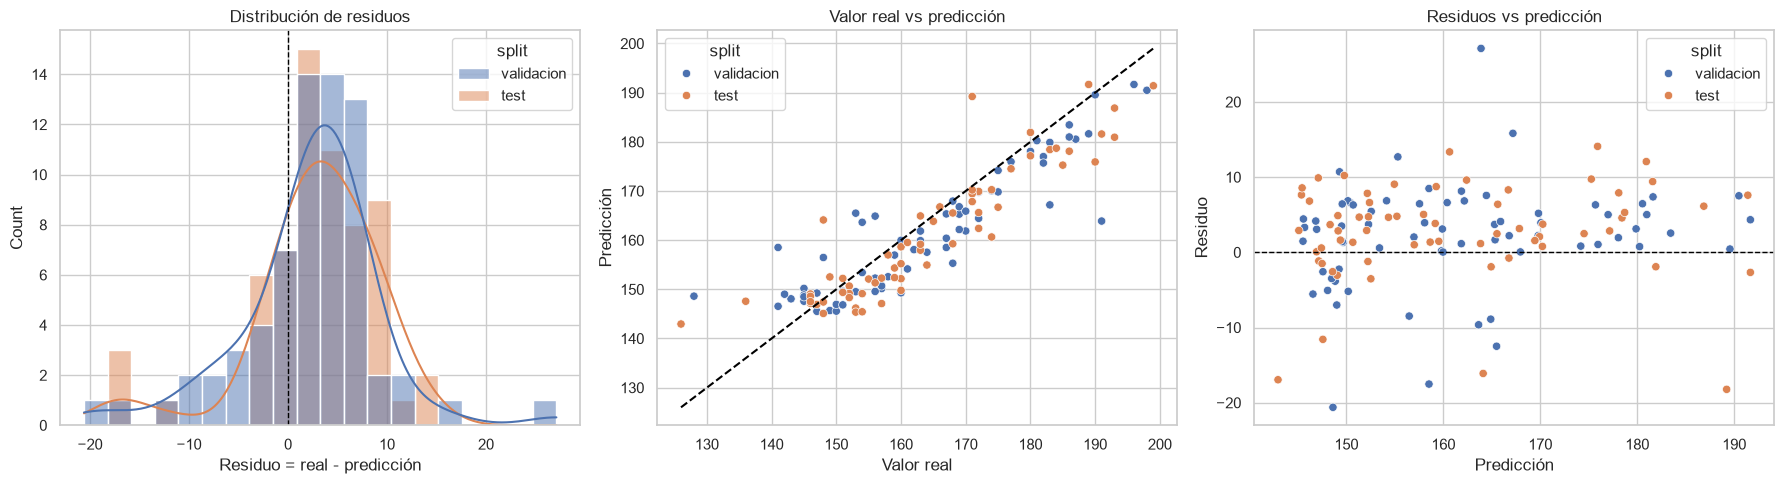

,split,residuo_medio,residuo_mediano,mae,rmse,n
0,test,2.846,3.156,5.486,6.985,63
1,validacion,2.198,3.109,5.509,7.305,68


In [36]:
# Diagnóstico visual de residuos
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(
    data=predicciones_modelo,
    x='residuo',
    hue='split',
    kde=True,
    bins=20,
    ax=axes[0],
)
axes[0].axvline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_title('Distribución de residuos')
axes[0].set_xlabel('Residuo = real - predicción')

sns.scatterplot(
    data=predicciones_modelo,
    x='valor_real',
    y='prediccion',
    hue='split',
    ax=axes[1],
)
min_val = min(predicciones_modelo['valor_real'].min(), predicciones_modelo['prediccion'].min())
max_val = max(predicciones_modelo['valor_real'].max(), predicciones_modelo['prediccion'].max())
axes[1].plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--')
axes[1].set_title('Valor real vs predicción')
axes[1].set_xlabel('Valor real')
axes[1].set_ylabel('Predicción')

sns.scatterplot(
    data=predicciones_modelo,
    x='prediccion',
    y='residuo',
    hue='split',
    ax=axes[2],
)
axes[2].axhline(0, color='black', linestyle='--', linewidth=1)
axes[2].set_title('Residuos vs predicción')
axes[2].set_xlabel('Predicción')
axes[2].set_ylabel('Residuo')

plt.tight_layout()
plt.show()

resumen_residuos = (
    predicciones_modelo
    .groupby('split')
    .agg(
        residuo_medio=('residuo', 'mean'),
        residuo_mediano=('residuo', 'median'),
        mae=('error_absoluto', 'mean'),
        rmse=('error_cuadratico', lambda x: np.sqrt(x.mean())),
        n=('residuo', 'size'),
    )
    .round(3)
    .reset_index()
)

resumen_residuos

### 6.3 Análisis de errores por grupo

Se calculan errores agrupados por:

- región;
- departamento;
- institución;
- programa académico.

Para evitar sobreinterpretar grupos con pocos casos, se define:

```python
MIN_GRUPO_VALIDACION = 5
```

Los grupos con `n < 5` se muestran como evidencia descriptiva, pero no deben usarse para conclusiones fuertes.


In [37]:
# Error agrupado por variables de contexto
MIN_GRUPO_VALIDACION = 5

def analizar_error_por_grupo(tabla_predicciones, columna_grupo, nombre_split, min_grupo=MIN_GRUPO_VALIDACION):
    tabla_split = tabla_predicciones[tabla_predicciones['split'].eq(nombre_split)].copy()
    if tabla_split.empty:
        return pd.DataFrame(columns=[
            columna_grupo, 'n', 'MAE', 'RMSE', 'sesgo_medio',
            'promedio_real', 'promedio_predicho', 'grupo_confiable'
        ])

    resumen = (
        tabla_split
        .groupby(columna_grupo, dropna=False)
        .agg(
            n=('error_absoluto', 'size'),
            MAE=('error_absoluto', 'mean'),
            RMSE=('error_cuadratico', lambda x: np.sqrt(x.mean())),
            sesgo_medio=('residuo', 'mean'),
            promedio_real=('valor_real', 'mean'),
            promedio_predicho=('prediccion', 'mean'),
        )
        .reset_index()
    )
    resumen['grupo_confiable'] = resumen['n'] >= min_grupo
    columnas_redondeo = ['MAE', 'RMSE', 'sesgo_medio', 'promedio_real', 'promedio_predicho']
    resumen[columnas_redondeo] = resumen[columnas_redondeo].round(3)
    return resumen.sort_values(['grupo_confiable', 'MAE'], ascending=[False, False]).reset_index(drop=True)

analisis_region_test = analizar_error_por_grupo(predicciones_modelo, 'NOMBRE_REGION', 'test')
analisis_departamento_test = analizar_error_por_grupo(predicciones_modelo, 'NOMBRE_DEPARTAMENTO', 'test')
analisis_institucion_test = analizar_error_por_grupo(predicciones_modelo, 'NOMBRE_INSTITUCION', 'test')
analisis_programa_test = analizar_error_por_grupo(predicciones_modelo, 'NOMBRE_PROGRAMA_ACAD', 'test')

analisis_region_validacion = analizar_error_por_grupo(predicciones_modelo, 'NOMBRE_REGION', 'validacion')
analisis_departamento_validacion = analizar_error_por_grupo(predicciones_modelo, 'NOMBRE_DEPARTAMENTO', 'validacion')
analisis_institucion_validacion = analizar_error_por_grupo(predicciones_modelo, 'NOMBRE_INSTITUCION', 'validacion')
analisis_programa_validacion = analizar_error_por_grupo(predicciones_modelo, 'NOMBRE_PROGRAMA_ACAD', 'validacion')

print(f'Umbral mínimo para interpretar grupos: n >= {MIN_GRUPO_VALIDACION}')
print('Top regiones por MAE en test:')
display(analisis_region_test.head(10))
print('Top departamentos por MAE en test:')
display(analisis_departamento_test.head(10))
print('Top instituciones por MAE en test:')
display(analisis_institucion_test.head(10))
print('Top programas por MAE en test:')
display(analisis_programa_test.head(10))

Umbral mínimo para interpretar grupos: n >= 5
Top regiones por MAE en test:


,NOMBRE_REGION,n,MAE,RMSE,sesgo_medio,promedio_real,promedio_predicho,grupo_confiable
0,PACÍFICA,9,6.650,8.426,1.486,166.000,164.514,True
1,CARIBE,14,6.126,7.284,3.337,155.643,152.306,True
2,ANDINA,40,5.001,6.503,2.981,166.500,163.519,True


Top departamentos por MAE en test:


,NOMBRE_DEPARTAMENTO,n,MAE,RMSE,sesgo_medio,promedio_real,promedio_predicho,grupo_confiable
0,SANTANDER,5,10.217,11.201,3.774,165.200,161.426,True
1,VALLE,7,6.861,8.926,1.228,167.143,165.915,True
2,BOGOTÁ,17,4.695,5.978,2.657,166.706,164.049,True
3,ANTIOQUIA,6,3.911,4.489,1.847,167.667,165.820,True
4,CORDOBA,2,12.757,13.428,-4.190,140.000,144.190,False
5,CAUCA,1,8.300,8.300,8.300,175.000,166.700,False
6,CALDAS,2,7.061,9.459,6.294,170.000,163.706,False
7,ATLANTICO,4,5.584,6.130,5.584,163.750,158.166,False
8,CUNDINAMARCA,1,5.297,5.297,5.297,184.000,178.703,False
9,MAGDALENA,4,5.283,5.646,5.283,155.250,149.967,False


Top instituciones por MAE en test:


,NOMBRE_INSTITUCION,n,MAE,RMSE,sesgo_medio,promedio_real,promedio_predicho,grupo_confiable
0,FUNDACION UNIVERSITARIA SAN MARTIN,5,4.595,6.751,-0.495,149.8,150.295,True
1,UNIVERSIDAD DEL VALLE,1,18.222,18.222,-18.222,171.0,189.222,False
2,UNIVERSIDAD INDUSTRIAL DE SANTANDER,1,14.088,14.088,14.088,190.0,175.912,False
3,UNIVERSIDAD DE CALDAS,1,13.355,13.355,13.355,174.0,160.645,False
4,UNIVERSIDAD ICESI,1,12.064,12.064,12.064,193.0,180.936,False
5,UNIVERSIDAD DE SANTANDER,3,11.281,11.816,0.542,155.0,154.458,False
6,FUNDACION UNIVERSITARIA DEL AREA ANDINA,1,10.213,10.213,10.213,160.0,149.787,False
7,FUNDACION UNIVERSIDAD DEL NORTE,1,9.737,9.737,9.737,185.0,175.263,False
8,UNIVERSIDAD DEL SINÚ ELIAS BECHARA ZAINUM - UN...,3,9.731,11.167,-1.567,144.0,145.567,False
9,UNIVERSIDAD NACIONAL DE COLOMBIA,1,9.408,9.408,9.408,191.0,181.592,False


Top programas por MAE en test:


,NOMBRE_PROGRAMA_ACAD,n,MAE,RMSE,sesgo_medio,promedio_real,promedio_predicho,grupo_confiable
0,MEDICINA,63,5.486,6.985,2.846,164.016,161.17,True


### 6.4 Comparación contra baseline y revisión de generalización

Un modelo generaliza razonablemente si:

- supera al baseline en validación y test;
- no tiene una brecha excesiva entre entrenamiento y test;
- mantiene errores similares entre validación y test.

Esta revisión no reemplaza una validación estadística completa, pero permite detectar señales tempranas de sobreajuste.


In [38]:
# Comparación de generalización: mejor modelo vs baseline
modelos_generalizacion = ['Baseline media', mejor_modelo_nombre]
comparacion_generalizacion = (
    resultados_modelos[resultados_modelos['modelo'].isin(modelos_generalizacion)]
    .copy()
    .sort_values(['modelo', 'split'])
    .reset_index(drop=True)
)

metricas_mejor_modelo = comparacion_generalizacion[
    comparacion_generalizacion['modelo'].eq(mejor_modelo_nombre)
].copy()

mae_train_mejor = metricas_mejor_modelo.loc[metricas_mejor_modelo['split'].eq('entrenamiento'), 'MAE'].iloc[0]
mae_valid_mejor = metricas_mejor_modelo.loc[metricas_mejor_modelo['split'].eq('validacion'), 'MAE'].iloc[0]
mae_test_mejor = metricas_mejor_modelo.loc[metricas_mejor_modelo['split'].eq('test'), 'MAE'].iloc[0]

brecha_mae_validacion_train = round(mae_valid_mejor - mae_train_mejor, 3)
brecha_mae_test_train = round(mae_test_mejor - mae_train_mejor, 3)
brecha_mae_test_validacion = round(mae_test_mejor - mae_valid_mejor, 3)

print(f'Modelo evaluado: {mejor_modelo_nombre}')
print(f'Brecha MAE validación - entrenamiento: {brecha_mae_validacion_train}')
print(f'Brecha MAE test - entrenamiento: {brecha_mae_test_train}')
print(f'Brecha MAE test - validación: {brecha_mae_test_validacion}')

comparacion_generalizacion

Modelo evaluado: Random Forest
Brecha MAE validación - entrenamiento: -0.605
Brecha MAE test - entrenamiento: -0.628
Brecha MAE test - validación: -0.023


,modelo,split,MAE,RMSE,R2,n
0,Baseline media,entrenamiento,13.197,15.863,0.000,175
1,Baseline media,test,12.656,15.228,-0.009,63
2,Baseline media,validacion,13.013,15.475,-0.015,68
3,Random Forest,entrenamiento,6.114,9.164,0.666,175
4,Random Forest,test,5.486,6.985,0.788,63
5,Random Forest,validacion,5.509,7.305,0.774,68


### 6.5 Conclusión de validación

Esta conclusión resume la evidencia del benchmark inicial. Todavía no es una selección final del modelo para producción, porque falta revisar explicabilidad, robustez, ajustes y supuestos del caso de uso.


In [39]:
# Conclusión automática de validación
residuo_medio_test = float(
    resumen_residuos.loc[resumen_residuos['split'].eq('test'), 'residuo_medio'].iloc[0]
)

mae_baseline_test = float(
    resultados_modelos[
        resultados_modelos['modelo'].eq('Baseline media') &
        resultados_modelos['split'].eq('test')
    ]['MAE'].iloc[0]
)

mae_mejor_test = float(
    resultados_modelos[
        resultados_modelos['modelo'].eq(mejor_modelo_nombre) &
        resultados_modelos['split'].eq('test')
    ]['MAE'].iloc[0]
)

mejora_vs_baseline_test = round(mae_baseline_test - mae_mejor_test, 3)

mayor_region_test = analisis_region_test[analisis_region_test['grupo_confiable']].head(1)
mayor_departamento_test = analisis_departamento_test[analisis_departamento_test['grupo_confiable']].head(1)
mayor_institucion_test = analisis_institucion_test[analisis_institucion_test['grupo_confiable']].head(1)
mayor_programa_test = analisis_programa_test[analisis_programa_test['grupo_confiable']].head(1)

print('Conclusión:')
print(f'- El modelo limpio {mejor_modelo_nombre} mejora el MAE del baseline en test por {mejora_vs_baseline_test:.3f} puntos.')
print(f'- El residuo medio en test es {residuo_medio_test:.3f}; valores cercanos a cero sugieren bajo sesgo global.')
print(f'- La brecha MAE test-validación es {brecha_mae_test_validacion:.3f}; una brecha pequeña sugiere generalización razonable entre 2023 y 2024.')

if not mayor_region_test.empty:
    fila = mayor_region_test.iloc[0]
    print(f"- Región con mayor MAE confiable en test: {fila['NOMBRE_REGION']} (MAE={fila['MAE']}, n={int(fila['n'])}).")
if not mayor_departamento_test.empty:
    fila = mayor_departamento_test.iloc[0]
    print(f"- Departamento con mayor MAE confiable en test: {fila['NOMBRE_DEPARTAMENTO']} (MAE={fila['MAE']}, n={int(fila['n'])}).")
if not mayor_institucion_test.empty:
    fila = mayor_institucion_test.iloc[0]
    print(f"- Institución con mayor MAE confiable en test: {fila['NOMBRE_INSTITUCION']} (MAE={fila['MAE']}, n={int(fila['n'])}).")
if not mayor_programa_test.empty:
    fila = mayor_programa_test.iloc[0]
    print(f"- Programa con mayor MAE confiable en test: {fila['NOMBRE_PROGRAMA_ACAD']} (MAE={fila['MAE']}, n={int(fila['n'])}).")

print('- Corrección metodológica aplicada: cantidad_evaluados_* se conserva como contexto descriptivo, pero no se usa como predictor del modelo limpio pre-SHAP.')

Conclusión:
- El modelo limpio Random Forest mejora el MAE del baseline en test por 7.170 puntos.
- El residuo medio en test es 2.846; valores cercanos a cero sugieren bajo sesgo global.
- La brecha MAE test-validación es -0.023; una brecha pequeña sugiere generalización razonable entre 2023 y 2024.
- Región con mayor MAE confiable en test: PACÍFICA (MAE=6.65, n=9).
- Departamento con mayor MAE confiable en test: SANTANDER (MAE=10.217, n=5).
- Institución con mayor MAE confiable en test: FUNDACION UNIVERSITARIA SAN MARTIN (MAE=4.595, n=5).
- Programa con mayor MAE confiable en test: MEDICINA (MAE=5.486, n=63).
- Corrección metodológica aplicada: cantidad_evaluados_* se conserva como contexto descriptivo, pero no se usa como predictor del modelo limpio pre-SHAP.


### 6.6 Validaciones de la etapa

Estas pruebas verifican que las tablas de predicción y métricas sean consistentes antes de continuar con explicabilidad.


In [40]:
# Validaciones de la etapa de validación del modelo
for tabla, y_split, nombre_tabla in [
    (validacion_predicciones, y_valid, 'validacion_predicciones'),
    (test_predicciones, y_test, 'test_predicciones'),
]:
    assert len(tabla) == len(y_split), f'Filas inconsistentes en {nombre_tabla}'
    assert set(columnas_prediccion_requeridas).issubset(tabla.columns), f'Columnas faltantes en {nombre_tabla}'
    assert tabla['prediccion'].notna().all(), f'Predicciones nulas en {nombre_tabla}'
    assert np.isfinite(tabla['prediccion']).all(), f'Predicciones no finitas en {nombre_tabla}'
    assert np.isfinite(tabla['error_absoluto']).all(), f'Errores no finitos en {nombre_tabla}'
    assert np.isfinite(tabla['error_cuadratico']).all(), f'Errores cuadráticos no finitos en {nombre_tabla}'

assert set(['split', 'residuo_medio', 'mae', 'rmse', 'n']).issubset(resumen_residuos.columns)
assert np.isfinite(resumen_residuos[['residuo_medio', 'mae', 'rmse']].to_numpy()).all()
assert not analisis_region_test.empty
assert not analisis_departamento_test.empty
assert not analisis_institucion_test.empty
assert not analisis_programa_test.empty
assert mejor_modelo_nombre in comparacion_generalizacion['modelo'].unique()
assert 'Baseline media' in comparacion_generalizacion['modelo'].unique()

print('MODEL_VALIDATION_ANALYSIS_OK')
print(f'Filas de predicción validación: {len(validacion_predicciones)}')
print(f'Filas de predicción test: {len(test_predicciones)}')
print(f'Residuo medio test: {residuo_medio_test:.3f}')
print(f'Mejora MAE vs baseline en test: {mejora_vs_baseline_test:.3f}')

MODEL_VALIDATION_ANALYSIS_OK
Filas de predicción validación: 68
Filas de predicción test: 63
Residuo medio test: 2.846
Mejora MAE vs baseline en test: 7.170


## Próxima etapa

La siguiente etapa del PDR es **IA Explicable con SHAP**.

El modelo candidato para explicar debe ser el modelo limpio seleccionado en esta etapa, no el benchmark anterior con `cantidad_evaluados_*`. SHAP debe responder qué variables históricas y contextuales explican las predicciones sin depender de variables operativas del mismo periodo.

## 7. IA Explicable con SHAP

Esta etapa explica el modelo limpio seleccionado antes de construir recomendaciones o dashboard.

El modelo explicado es:

```text
Random Forest limpio sin cantidad_evaluados_*
```

Se usa SHAP porque permite estimar cuánto aporta cada variable a una predicción individual y al comportamiento global del modelo. Esto ayuda a responder preguntas como:

- ¿qué variables empujan una predicción hacia un `PROMEDIO_GLOBAL` más alto o más bajo?;
- ¿qué variables son más influyentes en promedio?;
- ¿cómo se explica una predicción concreta del conjunto de prueba?

Importante: esta etapa **no reintroduce** `cantidad_evaluados_media_pruebas` ni `cantidad_evaluados_max_pruebas`, porque son variables operativas del mismo periodo y podrían no estar disponibles antes de predecir.

### 7.1 Configuración robusta de SHAP

En Google Colab, si SHAP no está instalado, ejecutá una vez:

```python
# !pip install shap
```

Para que el notebook siga siendo ejecutable en ambientes locales donde `shap` no esté disponible, la celda siguiente usa un modo seguro: si no encuentra SHAP, muestra instrucciones claras y continúa con importancia nativa del Random Forest.

In [41]:
# Configuración robusta de SHAP
# En Colab, si esta celda informa que SHAP no está instalado, ejecutá:
# !pip install shap

try:
    import shap
    SHAP_AVAILABLE = True
    print(f'SHAP disponible: {shap.__version__}')
except ModuleNotFoundError:
    shap = None
    SHAP_AVAILABLE = False
    print('SHAP no está instalado en este entorno.')
    print('Para generar gráficos SHAP en Colab, ejecutá primero:')
    print('# !pip install shap')
    print('El notebook continuará con importancia nativa del Random Forest y omitirá los gráficos SHAP.')

SHAP no está instalado en este entorno.
Para generar gráficos SHAP en Colab, ejecutá primero:
# !pip install shap
El notebook continuará con importancia nativa del Random Forest y omitirá los gráficos SHAP.


### 7.2 Extracción del modelo, preprocesamiento y matriz transformada

El modelo está dentro de un `Pipeline` de scikit-learn:

1. `preprocesamiento`: imputa, escala y codifica variables.
2. `modelo`: Random Forest entrenado.

Para explicar correctamente el modelo, SHAP debe recibir la misma matriz transformada que recibe internamente el Random Forest.

In [42]:
# Extraer modelo entrenado y matriz preprocesada para explicabilidad
from scipy import sparse

assert 'mejor_modelo' in globals(), 'Falta mejor_modelo. Ejecutá primero la etapa 5.'
assert 'mejor_modelo_nombre' in globals(), 'Falta mejor_modelo_nombre. Ejecutá primero la etapa 5.'
assert mejor_modelo_nombre == 'Random Forest', f'El modelo esperado para SHAP era Random Forest, pero es {mejor_modelo_nombre}'
assert hasattr(mejor_modelo, 'named_steps'), 'mejor_modelo debe ser un Pipeline de scikit-learn.'

preprocesador_explicabilidad = mejor_modelo.named_steps['preprocesamiento']
estimador_explicabilidad = mejor_modelo.named_steps['modelo']

assert isinstance(estimador_explicabilidad, RandomForestRegressor)

feature_names_transformadas = preprocesador_explicabilidad.get_feature_names_out()

X_explicabilidad_base = X_test.copy() if len(X_test) > 0 else X_valid.copy()
y_explicabilidad_base = y_test.copy() if len(X_test) > 0 else y_valid.copy()
split_explicabilidad = 'test' if len(X_test) > 0 else 'validacion'

MAX_FILAS_SHAP = 100
X_explicabilidad_sample = X_explicabilidad_base.head(MAX_FILAS_SHAP).copy()
y_explicabilidad_sample = y_explicabilidad_base.loc[X_explicabilidad_sample.index].copy()

X_explicabilidad_transformada = preprocesador_explicabilidad.transform(X_explicabilidad_sample)
if sparse.issparse(X_explicabilidad_transformada):
    X_explicabilidad_transformada = X_explicabilidad_transformada.toarray()

assert len(feature_names_transformadas) == X_explicabilidad_transformada.shape[1]
assert not any('cantidad_evaluados' in nombre for nombre in feature_names_transformadas)

print(f'Modelo explicado: {mejor_modelo_nombre}')
print(f'Split usado para explicabilidad: {split_explicabilidad}')
print(f'Filas usadas: {X_explicabilidad_transformada.shape[0]}')
print(f'Variables transformadas: {X_explicabilidad_transformada.shape[1]}')
print('Validación: no hay cantidad_evaluados_* en las variables transformadas.')

Modelo explicado: Random Forest
Split usado para explicabilidad: test
Filas usadas: 63
Variables transformadas: 97
Validación: no hay cantidad_evaluados_* en las variables transformadas.


### 7.3 Importancia nativa del Random Forest

Antes de SHAP, se calcula una referencia simple: la importancia nativa del Random Forest (`feature_importances_`).

Esta tabla indica qué variables transformadas fueron más usadas por los árboles para reducir error. No explica dirección del efecto, pero sirve como comparación inicial.

In [43]:
# Importancia nativa del Random Forest
importancias_rf = pd.DataFrame({
    'feature_transformada': feature_names_transformadas,
    'importancia_rf': estimador_explicabilidad.feature_importances_,
})

importancias_rf = importancias_rf.sort_values('importancia_rf', ascending=False).reset_index(drop=True)

def mapear_feature_original(nombre_feature):
    nombre = str(nombre_feature)
    if nombre.startswith('numericas__'):
        return nombre.replace('numericas__', '')
    if nombre.startswith('categoricas__'):
        resto = nombre.replace('categoricas__', '')
        for columna in features_categoricas:
            prefijo = f'{columna}_'
            if resto.startswith(prefijo):
                return columna
        return resto
    return nombre

importancias_rf['feature_original'] = importancias_rf['feature_transformada'].map(mapear_feature_original)

importancia_rf_agrupada = (
    importancias_rf
    .groupby('feature_original', as_index=False)['importancia_rf']
    .sum()
    .sort_values('importancia_rf', ascending=False)
    .reset_index(drop=True)
)

print('Top 10 variables transformadas según Random Forest:')
display(importancias_rf.head(10))

print('Importancia agrupada por variable original:')
display(importancia_rf_agrupada)

Top 10 variables transformadas según Random Forest:


,feature_transformada,importancia_rf,feature_original
0,numericas__promedio_global_anterior,0.407033,promedio_global_anterior
1,numericas__promedio_movil_2_anios,0.381446,promedio_movil_2_anios
2,categoricas__NOMBRE_REGION_CARIBE,0.070319,NOMBRE_REGION
3,numericas__AÑO,0.030181,AÑO
4,categoricas__NOMBRE_INSTITUCION_FUNDACION UNIV...,0.020611,NOMBRE_INSTITUCION
5,categoricas__NOMBRE_REGION_ANDINA,0.010563,NOMBRE_REGION
6,numericas__anios_historicos_disponibles,0.010275,anios_historicos_disponibles
7,categoricas__NOMBRE_MUNICIPIO_CARTAGENA DE INDIAS,0.010057,NOMBRE_MUNICIPIO
8,categoricas__NOMBRE_INSTITUCION_UNIVERSIDAD CO...,0.008997,NOMBRE_INSTITUCION
9,categoricas__NOMBRE_DEPARTAMENTO_BOLIVAR,0.008749,NOMBRE_DEPARTAMENTO


Importancia agrupada por variable original:


,feature_original,importancia_rf
0,promedio_global_anterior,0.407033
1,promedio_movil_2_anios,0.381446
2,NOMBRE_REGION,0.082026
3,NOMBRE_INSTITUCION,0.032533
4,AÑO,0.030181
5,NOMBRE_MUNICIPIO,0.028747
6,NOMBRE_DEPARTAMENTO,0.025152
7,anios_historicos_disponibles,0.010275
8,desviacion_historica_2_anios,0.002608
9,NOMBRE_PROGRAMA_ACAD,0.000000


**Interpretación:**

- La tabla de variables transformadas muestra el detalle después del `OneHotEncoder`.
- La tabla agrupada por variable original es más fácil de leer para el informe académico.
- Si una variable categórica aparece muy arriba, significa que ciertas categorías de esa variable ayudan a separar programas con distintos niveles de `PROMEDIO_GLOBAL`.
- Esta importancia no implica causalidad; solo describe qué señales usó el modelo.

### 7.4 Cálculo de valores SHAP

Cuando SHAP está disponible, se usa `TreeExplainer`, adecuado para modelos basados en árboles como Random Forest.

Los valores SHAP indican cuánto aporta cada variable transformada a cada predicción respecto del valor base del modelo.

In [44]:
# Calcular valores SHAP si el paquete está disponible
if SHAP_AVAILABLE:
    explainer_shap = shap.TreeExplainer(estimador_explicabilidad)
    shap_values_raw = explainer_shap.shap_values(X_explicabilidad_transformada)

    if isinstance(shap_values_raw, list):
        shap_values = shap_values_raw[0]
    else:
        shap_values = shap_values_raw

    shap_values = np.asarray(shap_values)
    expected_value_shap = explainer_shap.expected_value
    if isinstance(expected_value_shap, (list, np.ndarray)):
        expected_value_shap = float(np.ravel(expected_value_shap)[0])
    else:
        expected_value_shap = float(expected_value_shap)

    importancia_shap = pd.DataFrame({
        'feature_transformada': feature_names_transformadas,
        'mean_abs_shap': np.abs(shap_values).mean(axis=0),
    })
    importancia_shap['feature_original'] = importancia_shap['feature_transformada'].map(mapear_feature_original)
    importancia_shap = importancia_shap.sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

    importancia_shap_agrupada = (
        importancia_shap
        .groupby('feature_original', as_index=False)['mean_abs_shap']
        .sum()
        .sort_values('mean_abs_shap', ascending=False)
        .reset_index(drop=True)
    )

    print('SHAP calculado correctamente.')
    print(f'Expected value: {expected_value_shap:.3f}')
    display(importancia_shap.head(10))
    display(importancia_shap_agrupada)
else:
    explainer_shap = None
    shap_values = None
    expected_value_shap = None
    importancia_shap = pd.DataFrame(columns=['feature_transformada', 'feature_original', 'mean_abs_shap'])
    importancia_shap_agrupada = pd.DataFrame(columns=['feature_original', 'mean_abs_shap'])
    print('SHAP no disponible: se omite el cálculo de valores SHAP en este entorno.')
    print('Referencia disponible: importancias nativas del Random Forest calculadas en la sección 7.3.')

SHAP no disponible: se omite el cálculo de valores SHAP en este entorno.
Referencia disponible: importancias nativas del Random Forest calculadas en la sección 7.3.


**Interpretación:**

- `mean_abs_shap` mide la magnitud promedio del impacto de cada variable en las predicciones.
- A diferencia de la importancia nativa del Random Forest, SHAP permite analizar impacto global e impacto individual.
- Si SHAP no está instalado, el notebook mantiene trazabilidad mediante la tabla de importancia nativa y deja la instrucción de instalación para Colab.

### 7.5 SHAP summary plot

El `summary plot` muestra, para cada variable, cómo se distribuyen sus impactos SHAP en las predicciones.

Cuando está disponible, ayuda a ver qué variables tienen mayor impacto global y si tienden a subir o bajar el valor predicho.

In [45]:
# SHAP summary plot
if SHAP_AVAILABLE:
    shap.summary_plot(
        shap_values,
        X_explicabilidad_transformada,
        feature_names=feature_names_transformadas,
        show=False,
        max_display=15,
    )
    plt.title('SHAP summary plot - Random Forest limpio')
    plt.tight_layout()
    plt.show()
else:
    print('SHAP summary plot omitido porque SHAP no está instalado.')
    print('En Colab: ejecutá # !pip install shap y reiniciá la ejecución del notebook.')

SHAP summary plot omitido porque SHAP no está instalado.
En Colab: ejecutá # !pip install shap y reiniciá la ejecución del notebook.


**Interpretación:**

- Las variables ubicadas arriba son las de mayor impacto promedio.
- Cada punto representa una fila del conjunto usado para explicar.
- Valores SHAP positivos empujan la predicción hacia un `PROMEDIO_GLOBAL` más alto; valores negativos la empujan hacia abajo.
- Si la gráfica fue omitida por falta de SHAP, usá como referencia temporal la tabla de importancia nativa.

### 7.6 SHAP dependence plot para la variable principal

El `dependence plot` permite revisar cómo cambia el impacto SHAP de la variable más importante a medida que cambia su valor.

In [46]:
# SHAP dependence plot para la variable más importante
if SHAP_AVAILABLE and not importancia_shap.empty:
    top_feature_shap = importancia_shap.iloc[0]['feature_transformada']
    top_feature_idx = int(np.where(feature_names_transformadas == top_feature_shap)[0][0])

    shap.dependence_plot(
        top_feature_idx,
        shap_values,
        X_explicabilidad_transformada,
        feature_names=feature_names_transformadas,
        show=False,
    )
    plt.title(f'SHAP dependence plot - {top_feature_shap}')
    plt.tight_layout()
    plt.show()
    print(f'Variable usada en dependence plot: {top_feature_shap}')
else:
    top_feature_shap = None
    print('SHAP dependence plot omitido porque SHAP no está instalado.')

SHAP dependence plot omitido porque SHAP no está instalado.


**Interpretación:**

- Este gráfico permite observar si el impacto de la variable principal crece, cae o cambia de forma no lineal.
- En variables codificadas con One-Hot, el valor suele ser 0/1: el gráfico compara el impacto de pertenecer o no a esa categoría.
- La lectura debe hacerse como asociación aprendida por el modelo, no como causalidad.

### 7.7 SHAP waterfall plot para una predicción individual

El `waterfall plot` explica una fila concreta: parte del valor base del modelo y suma/resta los aportes de cada variable hasta llegar a la predicción final.

In [47]:
# SHAP waterfall plot para una predicción representativa
predicciones_explicabilidad = estimador_explicabilidad.predict(X_explicabilidad_transformada)
indice_representativo = int(np.argsort(np.abs(predicciones_explicabilidad - np.median(predicciones_explicabilidad)))[0])

fila_contexto_representativa = X_explicabilidad_sample.iloc[[indice_representativo]].copy()
valor_real_representativo = float(y_explicabilidad_sample.iloc[indice_representativo])
prediccion_representativa = float(predicciones_explicabilidad[indice_representativo])

print('Fila representativa para explicación individual:')
print(f'Índice interno de muestra: {indice_representativo}')
print(f'Valor real: {valor_real_representativo:.3f}')
print(f'Predicción: {prediccion_representativa:.3f}')
display(fila_contexto_representativa)

if SHAP_AVAILABLE:
    explicacion_individual = shap.Explanation(
        values=shap_values[indice_representativo],
        base_values=expected_value_shap,
        data=X_explicabilidad_transformada[indice_representativo],
        feature_names=feature_names_transformadas,
    )
    shap.plots.waterfall(explicacion_individual, max_display=15, show=False)
    plt.title('SHAP waterfall plot - predicción individual')
    plt.tight_layout()
    plt.show()
else:
    explicacion_individual = None
    print('SHAP waterfall plot omitido porque SHAP no está instalado.')

Fila representativa para explicación individual:
Índice interno de muestra: 19
Valor real: 160.000
Predicción: 158.641


,AÑO,promedio_global_anterior,promedio_movil_2_anios,desviacion_historica_2_anios,anios_historicos_disponibles,NOMBRE_REGION,NOMBRE_DEPARTAMENTO,NOMBRE_MUNICIPIO,NOMBRE_INSTITUCION,NOMBRE_PROGRAMA_ACAD
92,2024,164.0,162.0,2.828427,4,ANDINA,BOGOTÁ,BOGOTÁ D.C.,UNIVERSIDAD DE CIENCIAS APLICADAS Y AMBIENTALE...,MEDICINA


SHAP waterfall plot omitido porque SHAP no está instalado.


**Interpretación:**

- La predicción individual debe leerse como suma de aportes sobre un valor base.
- Las variables que empujan hacia arriba aumentan el promedio global predicho.
- Las variables que empujan hacia abajo reducen el promedio global predicho.
- Esta explicación sirve para auditar casos concretos, especialmente predicciones con alto error o instituciones específicas.

### 7.8 Validaciones de explicabilidad

Estas validaciones aseguran que la explicación se generó sobre el modelo limpio y que las matrices tienen dimensiones consistentes.

In [48]:
# Validaciones de IA Explicable
assert mejor_modelo_nombre == 'Random Forest'
assert len(feature_names_transformadas) == X_explicabilidad_transformada.shape[1]
assert not any('cantidad_evaluados' in nombre for nombre in feature_names_transformadas)
assert X_explicabilidad_transformada.shape[0] == len(X_explicabilidad_sample)
assert not importancias_rf.empty
assert 'cantidad_evaluados_media_pruebas' not in features_modelo
assert 'cantidad_evaluados_max_pruebas' not in features_modelo

if SHAP_AVAILABLE:
    assert shap_values is not None
    assert shap_values.shape == X_explicabilidad_transformada.shape
    assert not importancia_shap.empty
    status_explicabilidad = 'SHAP_AVAILABLE_VALIDATION_OK'
else:
    status_explicabilidad = 'SHAP_NOT_AVAILABLE_FALLBACK_OK'

print(status_explicabilidad)
print(f'Modelo explicado: {mejor_modelo_nombre}')
print(f'SHAP disponible: {SHAP_AVAILABLE}')
print(f'Top RF feature original: {importancia_rf_agrupada.iloc[0]["feature_original"]}')
if SHAP_AVAILABLE:
    print(f'Top SHAP feature original: {importancia_shap_agrupada.iloc[0]["feature_original"]}')
else:
    print('Top SHAP feature original: no disponible en este entorno')

SHAP_NOT_AVAILABLE_FALLBACK_OK
Modelo explicado: Random Forest
SHAP disponible: False
Top RF feature original: promedio_global_anterior
Top SHAP feature original: no disponible en este entorno


### 7.9 Conclusión de IA Explicable

La etapa deja preparado el notebook para explicar el modelo limpio con SHAP cuando el paquete esté disponible.

En entornos sin SHAP instalado, el notebook no falla: conserva la validación, muestra instrucciones de instalación para Colab y presenta la importancia nativa del Random Forest como referencia mínima.

No se implementan todavía recomendaciones, dashboard ni Streamlit.

## 8. Sistema de recomendaciones

Esta etapa convierte los resultados descriptivos, históricos y predictivos en recomendaciones de apoyo a la decisión.

Principios metodológicos:

- Las recomendaciones son **basadas en evidencia observada**, no en intuición.
- Son **descriptivas y de apoyo a la decisión**; no prueban causalidad.
- No se afirma que una variable “cause” el desempeño; se reportan señales históricas, predicciones, errores del modelo y estabilidad reciente.
- Cada recomendación debe incluir evidencia numérica suficiente para que pueda ser auditada.
- Si falta una evidencia central —por ejemplo, predicción en test 2024 o historial previo— el texto debe decirlo explícitamente.

No se implementa todavía dashboard ni Streamlit.

### 8.1 Construcción de la tabla base de recomendaciones

La tabla `recomendaciones_programa` se construye a nivel institución-programa usando el último año disponible por programa. Cuando existe predicción de test 2024, se usa como evidencia predictiva; cuando no existe, se mantiene el registro histórico más reciente y se marca la ausencia de predicción test.

In [49]:
# Construir tabla base de recomendaciones por institución y programa
llaves_recomendacion = ['ID_INSTITUCION', 'ID_PROGRAMA_ACAD']
columnas_contexto_recomendacion = [
    'AÑO',
    'ID_REGION', 'NOMBRE_REGION',
    'ID_DEPARTAMENTO', 'NOMBRE_DEPARTAMENTO',
    'ID_MUNICIPIO', 'NOMBRE_MUNICIPIO',
    'ID_INSTITUCION', 'NOMBRE_INSTITUCION',
    'ID_PROGRAMA_ACAD', 'NOMBRE_PROGRAMA_ACAD',
]

columnas_evidencia_historica = [
    'promedio_global_anual',
    'promedio_global_anterior',
    'variacion_anual',
    'variacion_porcentual',
    'promedio_movil_2_anios',
    'desviacion_historica_2_anios',
    'crecimiento_acumulado_desde_inicio',
    'anios_historicos_disponibles',
]

idx_ultimo_anio_programa = (
    medicina_features
    .sort_values(llaves_recomendacion + ['AÑO'])
    .groupby(llaves_recomendacion, dropna=False)['AÑO']
    .idxmax()
)

recomendaciones_programa = (
    medicina_features
    .loc[idx_ultimo_anio_programa, columnas_contexto_recomendacion + columnas_evidencia_historica]
    .copy()
    .sort_values(['NOMBRE_INSTITUCION', 'NOMBRE_PROGRAMA_ACAD', 'ID_PROGRAMA_ACAD'])
    .reset_index(drop=True)
)

# Se predice sobre el último año disponible de cada programa con el modelo limpio.
# Solo se considera "test" cuando el último año es 2024, porque esa fue la partición holdout.
recomendaciones_programa['prediccion_modelo'] = mejor_modelo.predict(recomendaciones_programa[features_modelo])
recomendaciones_programa['tiene_prediccion_test'] = recomendaciones_programa['AÑO'].eq(2024)
recomendaciones_programa['valor_real_test'] = np.where(
    recomendaciones_programa['tiene_prediccion_test'],
    recomendaciones_programa['promedio_global_anual'],
    np.nan,
)
recomendaciones_programa['prediccion_test'] = np.where(
    recomendaciones_programa['tiene_prediccion_test'],
    recomendaciones_programa['prediccion_modelo'],
    np.nan,
)
recomendaciones_programa['residuo_test'] = np.where(
    recomendaciones_programa['tiene_prediccion_test'],
    recomendaciones_programa['valor_real_test'] - recomendaciones_programa['prediccion_test'],
    np.nan,
)
recomendaciones_programa['error_absoluto_test'] = np.abs(recomendaciones_programa['residuo_test'])
recomendaciones_programa['split_prediccion'] = np.where(
    recomendaciones_programa['tiene_prediccion_test'],
    'test',
    'aplicacion_ultimo_anio_no_test',
)
recomendaciones_programa['modelo_prediccion'] = mejor_modelo_nombre
recomendaciones_programa['valor_observado_reciente'] = recomendaciones_programa['promedio_global_anual']
recomendaciones_programa['fuente_evidencia'] = np.where(
    recomendaciones_programa['tiene_prediccion_test'],
    'test_2024_con_prediccion',
    'ultimo_anio_disponible_con_prediccion_fuera_de_test'
)

print(f'Recomendaciones candidatas: {recomendaciones_programa.shape[0]}')
print(f'Con predicción test 2024: {int(recomendaciones_programa["tiene_prediccion_test"].sum())}')
print(f'Sin predicción test 2024: {int((~recomendaciones_programa["tiene_prediccion_test"]).sum())}')
recomendaciones_programa.head()


Recomendaciones candidatas: 70
Con predicción test 2024: 63
Sin predicción test 2024: 7


,AÑO,ID_REGION,NOMBRE_REGION,ID_DEPARTAMENTO,NOMBRE_DEPARTAMENTO,ID_MUNICIPIO,NOMBRE_MUNICIPIO,ID_INSTITUCION,NOMBRE_INSTITUCION,ID_PROGRAMA_ACAD,NOMBRE_PROGRAMA_ACAD,promedio_global_anual,promedio_global_anterior,variacion_anual,variacion_porcentual,promedio_movil_2_anios,desviacion_historica_2_anios,crecimiento_acumulado_desde_inicio,anios_historicos_disponibles,prediccion_modelo,tiene_prediccion_test,valor_real_test,prediccion_test,residuo_test,error_absoluto_test,split_prediccion,modelo_prediccion,valor_observado_reciente,fuente_evidencia
0,2024,2.0,ANDINA,4.0,BOGOTÁ,152.0,BOGOTÁ D.C.,9003.0,COLEGIO MAYOR DE NUESTRA SEÑORA DEL ROSARIO,570.0,MEDICINA,193.0,189.0,4.0,2.116402,188.0,1.414214,9.0,4,186.866202,True,193.0,186.866202,6.133798,6.133798,test,Random Forest,193.0,test_2024_con_prediccion
1,2024,2.0,ANDINA,20.0,QUINDIO,824.0,ARMENIA,9156.0,CORPORACION UNIVERSITARIA EMPRESARIAL ALEXANDE...,8999.0,MEDICINA,155.0,157.0,-2.0,-1.273885,153.0,5.656854,-7.0,4,152.093650,True,155.0,152.093650,2.906350,2.906350,test,Random Forest,155.0,test_2024_con_prediccion
2,2024,3.0,CARIBE,5.0,BOLIVAR,153.0,CARTAGENA DE INDIAS,9084.0,CORPORACION UNIVERSITARIA RAFAEL NUÑEZ,5661.0,MEDICINA,146.0,143.0,3.0,2.097902,144.0,1.414214,-2.0,4,148.576876,True,146.0,148.576876,-2.576876,2.576876,test,Random Forest,146.0,test_2024_con_prediccion
3,2024,2.0,ANDINA,1.0,ANTIOQUIA,1.0,MEDELLÍN,8903.0,CORPORACION UNIVERSITARIA REMINGTON,2329.0,MEDICINA,146.0,145.0,1.0,0.689655,148.0,4.242641,-9.0,4,149.053595,True,146.0,149.053595,-3.053595,3.053595,test,Random Forest,146.0,test_2024_con_prediccion
4,2024,3.0,CARIBE,2.0,ATLANTICO,126.0,BARRANQUILLA,8941.0,FUNDACION UNIVERSIDAD DEL NORTE,6919.0,MEDICINA,185.0,180.0,5.0,2.777778,182.0,2.828427,-5.0,4,175.263313,True,185.0,175.263313,9.736687,9.736687,test,Random Forest,185.0,test_2024_con_prediccion


### 8.2 Umbrales calibrados con cuantiles

Para evitar constantes arbitrarias, los umbrales se calculan desde la distribución de la propia tabla de recomendaciones:

- desempeño bajo: cuartil 25 de `valor_observado_reciente`;
- desempeño alto: cuartil 75 de `valor_observado_reciente`;
- tendencia descendente fuerte: cuartil 25 de `variacion_anual`;
- tendencia positiva fuerte: cuartil 75 de `variacion_anual`;
- volatilidad alta: cuartil 75 de `desviacion_historica_2_anios`;
- estabilidad: cuartil 25 de `desviacion_historica_2_anios` y baja variación absoluta;
- incertidumbre del modelo: cuartil 75 del error absoluto en test.

In [50]:
# Calibrar umbrales de recomendación con cuantiles observados
def cuantile_or_nan(serie, q):
    serie_limpia = pd.to_numeric(serie, errors='coerce').dropna()
    if serie_limpia.empty:
        return np.nan
    return float(serie_limpia.quantile(q))

umbrales_recomendacion = {
    'desempeno_bajo_q25': cuantile_or_nan(recomendaciones_programa['valor_observado_reciente'], 0.25),
    'desempeno_alto_q75': cuantile_or_nan(recomendaciones_programa['valor_observado_reciente'], 0.75),
    'prediccion_baja_q25': cuantile_or_nan(recomendaciones_programa['prediccion_modelo'], 0.25),
    'prediccion_alta_q75': cuantile_or_nan(recomendaciones_programa['prediccion_modelo'], 0.75),
    'variacion_descendente_q25': cuantile_or_nan(recomendaciones_programa['variacion_anual'], 0.25),
    'variacion_positiva_q75': cuantile_or_nan(recomendaciones_programa['variacion_anual'], 0.75),
    'volatilidad_alta_q75': cuantile_or_nan(recomendaciones_programa['desviacion_historica_2_anios'], 0.75),
    'volatilidad_baja_q25': cuantile_or_nan(recomendaciones_programa['desviacion_historica_2_anios'], 0.25),
    'variacion_abs_baja_q25': cuantile_or_nan(recomendaciones_programa['variacion_anual'].abs(), 0.25),
    'error_alto_test_q75': cuantile_or_nan(recomendaciones_programa['error_absoluto_test'], 0.75),
}

pd.DataFrame.from_dict(umbrales_recomendacion, orient='index', columns=['valor']).round(3)


,valor
desempeno_bajo_q25,152.000
desempeno_alto_q75,172.000
prediccion_baja_q25,149.481
prediccion_alta_q75,169.041
variacion_descendente_q25,-3.250
variacion_positiva_q75,3.250
volatilidad_alta_q75,2.828
volatilidad_baja_q25,0.707
variacion_abs_baja_q25,1.000
error_alto_test_q75,8.104


### 8.3 Reglas de categorización

Las categorías se asignan con reglas transparentes. Una misma fila puede tener varias banderas de evidencia, pero se selecciona una `categoria_recomendacion` principal para facilitar el análisis.

In [51]:
# Crear banderas y categoría principal de recomendación
u = umbrales_recomendacion

recomendaciones_programa['bandera_desempeno_bajo'] = (
    (recomendaciones_programa['valor_observado_reciente'] <= u['desempeno_bajo_q25']) |
    (
        recomendaciones_programa['prediccion_modelo'].notna() &
        (recomendaciones_programa['prediccion_modelo'] <= u['prediccion_baja_q25'])
    )
)

recomendaciones_programa['bandera_desempeno_alto'] = (
    (recomendaciones_programa['valor_observado_reciente'] >= u['desempeno_alto_q75']) |
    (
        recomendaciones_programa['prediccion_modelo'].notna() &
        (recomendaciones_programa['prediccion_modelo'] >= u['prediccion_alta_q75'])
    )
)

recomendaciones_programa['bandera_tendencia_descendente'] = (
    recomendaciones_programa['variacion_anual'].notna() &
    (recomendaciones_programa['variacion_anual'] <= u['variacion_descendente_q25'])
)

recomendaciones_programa['bandera_tendencia_positiva'] = (
    recomendaciones_programa['variacion_anual'].notna() &
    (recomendaciones_programa['variacion_anual'] >= u['variacion_positiva_q75'])
)

recomendaciones_programa['bandera_volatilidad_alta'] = (
    recomendaciones_programa['desviacion_historica_2_anios'].notna() &
    (recomendaciones_programa['desviacion_historica_2_anios'] >= u['volatilidad_alta_q75'])
)

recomendaciones_programa['bandera_estabilidad'] = (
    recomendaciones_programa['desviacion_historica_2_anios'].notna() &
    recomendaciones_programa['variacion_anual'].notna() &
    (recomendaciones_programa['desviacion_historica_2_anios'] <= u['volatilidad_baja_q25']) &
    (recomendaciones_programa['variacion_anual'].abs() <= u['variacion_abs_baja_q25'])
)

recomendaciones_programa['bandera_error_modelo_alto'] = (
    recomendaciones_programa['error_absoluto_test'].notna() &
    (recomendaciones_programa['error_absoluto_test'] >= u['error_alto_test_q75'])
)

condiciones_categoria = [
    recomendaciones_programa['bandera_desempeno_bajo'] & recomendaciones_programa['bandera_tendencia_descendente'],
    recomendaciones_programa['bandera_desempeno_bajo'],
    recomendaciones_programa['bandera_error_modelo_alto'],
    recomendaciones_programa['bandera_desempeno_alto'] & (recomendaciones_programa['bandera_estabilidad'] | recomendaciones_programa['bandera_tendencia_positiva']),
    recomendaciones_programa['bandera_tendencia_descendente'],
    recomendaciones_programa['bandera_volatilidad_alta'],
    recomendaciones_programa['bandera_estabilidad'],
]

valores_categoria = [
    'riesgo_prioritario',
    'desempeno_bajo',
    'revisar_incertidumbre_modelo',
    'fortaleza_destacada',
    'tendencia_descendente',
    'alta_volatilidad',
    'estable',
]

recomendaciones_programa['categoria_recomendacion'] = np.select(
    condiciones_categoria,
    valores_categoria,
    default='seguimiento_regular'
)

resumen_recomendaciones_categoria = (
    recomendaciones_programa['categoria_recomendacion']
    .value_counts()
    .rename_axis('categoria_recomendacion')
    .reset_index(name='cantidad')
)

resumen_recomendaciones_categoria


,categoria_recomendacion,cantidad
0,desempeno_bajo,18
1,seguimiento_regular,14
2,revisar_incertidumbre_modelo,11
3,tendencia_descendente,9
4,riesgo_prioritario,6
5,fortaleza_destacada,5
6,alta_volatilidad,5
7,estable,2


### 8.4 Texto de recomendación

El texto se genera con frases auditables en español. Cada recomendación incluye valores de evidencia y evita afirmar causalidad.

In [52]:
# Generar texto explicativo de recomendación
def formatear_valor(valor, decimales=2):
    if pd.isna(valor):
        return 'no disponible'
    return f'{float(valor):.{decimales}f}'

def construir_texto_recomendacion(fila):
    partes = []
    partes.append(
        f"El programa {fila['NOMBRE_PROGRAMA_ACAD']} de {fila['NOMBRE_INSTITUCION']} "
        f"en {fila['NOMBRE_MUNICIPIO']}, {fila['NOMBRE_DEPARTAMENTO']}, "
        f"presenta categoría '{fila['categoria_recomendacion']}'."
    )

    partes.append(
        f"La evidencia reciente corresponde al año {int(fila['AÑO'])}: "
        f"PROMEDIO_GLOBAL observado={formatear_valor(fila['valor_observado_reciente'])}."
    )

    if fila['tiene_prediccion_test']:
        partes.append(
            f"El modelo limpio predijo {formatear_valor(fila['prediccion_modelo'])} "
            f"en test 2024 con error absoluto={formatear_valor(fila['error_absoluto_test'])}."
        )
    else:
        partes.append(
            f"No hay predicción de test 2024 para este programa; se muestra una predicción del modelo "
            f"sobre el último año disponible ({formatear_valor(fila['prediccion_modelo'])}), "
            "pero no se usa como error de test."
        )

    if pd.notna(fila['promedio_global_anterior']):
        partes.append(
            f"Frente al año anterior, la variación fue {formatear_valor(fila['variacion_anual'])} puntos "
            f"y el promedio móvil de 2 años previo fue {formatear_valor(fila['promedio_movil_2_anios'])}."
        )
    else:
        partes.append("No hay historial previo suficiente para calcular variación anual.")

    if pd.notna(fila['desviacion_historica_2_anios']):
        partes.append(
            f"La volatilidad histórica reciente fue {formatear_valor(fila['desviacion_historica_2_anios'])}."
        )
    else:
        partes.append("No hay suficientes años previos para estimar volatilidad histórica de 2 años.")

    if fila['categoria_recomendacion'] == 'riesgo_prioritario':
        partes.append("Recomendación: priorizar revisión académica y seguimiento, porque combina bajo desempeño relativo con señal descendente reciente.")
    elif fila['categoria_recomendacion'] == 'desempeno_bajo':
        partes.append("Recomendación: monitorear el desempeño y contrastar con factores institucionales antes de definir acciones.")
    elif fila['categoria_recomendacion'] == 'revisar_incertidumbre_modelo':
        partes.append("Recomendación: revisar este caso antes de usar la predicción, porque el error observado del modelo fue alto frente al resto del test.")
    elif fila['categoria_recomendacion'] == 'fortaleza_destacada':
        partes.append("Recomendación: documentar buenas prácticas y mantener seguimiento, porque el desempeño reciente es alto y estable o en mejora.")
    elif fila['categoria_recomendacion'] == 'tendencia_descendente':
        partes.append("Recomendación: analizar causas posibles con evidencia externa, porque el modelo solo identifica una señal descendente, no causalidad.")
    elif fila['categoria_recomendacion'] == 'alta_volatilidad':
        partes.append("Recomendación: interpretar con cautela y revisar estabilidad de cohortes, porque la variabilidad histórica reciente es alta.")
    elif fila['categoria_recomendacion'] == 'estable':
        partes.append("Recomendación: mantener seguimiento periódico; el comportamiento reciente es relativamente estable.")
    else:
        partes.append("Recomendación: mantener seguimiento regular; no se observan señales extremas con las reglas actuales.")

    partes.append("Esta lectura es descriptiva y no demuestra causalidad.")
    return ' '.join(partes)

recomendaciones_programa['texto_recomendacion'] = recomendaciones_programa.apply(construir_texto_recomendacion, axis=1)

columnas_salida_recomendaciones = [
    'AÑO', 'NOMBRE_REGION', 'NOMBRE_DEPARTAMENTO', 'NOMBRE_MUNICIPIO',
    'NOMBRE_INSTITUCION', 'NOMBRE_PROGRAMA_ACAD',
    'valor_observado_reciente', 'prediccion_modelo', 'error_absoluto_test',
    'variacion_anual', 'desviacion_historica_2_anios',
    'categoria_recomendacion', 'texto_recomendacion',
]

recomendaciones_programa[columnas_salida_recomendaciones].head(10)


,AÑO,NOMBRE_REGION,NOMBRE_DEPARTAMENTO,NOMBRE_MUNICIPIO,NOMBRE_INSTITUCION,NOMBRE_PROGRAMA_ACAD,valor_observado_reciente,prediccion_modelo,error_absoluto_test,variacion_anual,desviacion_historica_2_anios,categoria_recomendacion,texto_recomendacion
0,2024,ANDINA,BOGOTÁ,BOGOTÁ D.C.,COLEGIO MAYOR DE NUESTRA SEÑORA DEL ROSARIO,MEDICINA,193.0,186.866202,6.133798,4.0,1.414214,fortaleza_destacada,El programa MEDICINA de COLEGIO MAYOR DE NUEST...
1,2024,ANDINA,QUINDIO,ARMENIA,CORPORACION UNIVERSITARIA EMPRESARIAL ALEXANDE...,MEDICINA,155.0,152.093650,2.906350,-2.0,5.656854,alta_volatilidad,El programa MEDICINA de CORPORACION UNIVERSITA...
2,2024,CARIBE,BOLIVAR,CARTAGENA DE INDIAS,CORPORACION UNIVERSITARIA RAFAEL NUÑEZ,MEDICINA,146.0,148.576876,2.576876,3.0,1.414214,desempeno_bajo,El programa MEDICINA de CORPORACION UNIVERSITA...
3,2024,ANDINA,ANTIOQUIA,MEDELLÍN,CORPORACION UNIVERSITARIA REMINGTON,MEDICINA,146.0,149.053595,3.053595,1.0,4.242641,desempeno_bajo,El programa MEDICINA de CORPORACION UNIVERSITA...
4,2024,CARIBE,ATLANTICO,BARRANQUILLA,FUNDACION UNIVERSIDAD DEL NORTE,MEDICINA,185.0,175.263313,9.736687,5.0,2.828427,revisar_incertidumbre_modelo,El programa MEDICINA de FUNDACION UNIVERSIDAD ...
5,2024,ANDINA,ANTIOQUIA,MEDELLÍN,FUNDACION UNIVERSITARIA AUTONOMA DE LAS AMERICAS,MEDICINA,151.0,152.221343,1.221343,-6.0,3.535534,riesgo_prioritario,El programa MEDICINA de FUNDACION UNIVERSITARI...
6,2024,ANDINA,BOGOTÁ,BOGOTÁ D.C.,FUNDACION UNIVERSITARIA DE CIENCIAS DE LA SALUD,MEDICINA,172.0,165.611639,6.388361,4.0,2.121320,fortaleza_destacada,El programa MEDICINA de FUNDACION UNIVERSITARI...
7,2024,ANDINA,BOGOTÁ,BOGOTÁ D.C.,FUNDACION UNIVERSITARIA DEL AREA ANDINA,MEDICINA,160.0,149.786697,10.213303,6.0,NaN,revisar_incertidumbre_modelo,El programa MEDICINA de FUNDACION UNIVERSITARI...
8,2024,ANDINA,BOGOTÁ,BOGOTÁ D.C.,FUNDACION UNIVERSITARIA JUAN N. CORPAS,MEDICINA,154.0,149.121627,4.878373,1.0,2.121320,desempeno_bajo,El programa MEDICINA de FUNDACION UNIVERSITARI...
9,2024,ANDINA,HUILA,NEIVA,FUNDACION UNIVERSITARIA NAVARRA - UNINAVARRA,MEDICINA,151.0,149.379714,1.620286,4.0,4.949747,desempeno_bajo,El programa MEDICINA de FUNDACION UNIVERSITARI...


### 8.5 Resúmenes para toma de decisiones

Se generan tablas de conteo por categoría, casos de mayor riesgo, casos destacados y agregaciones territoriales. Estas salidas sirven como insumo para el informe, no como dashboard.

In [53]:
# Resúmenes de recomendaciones
categorias_riesgo = ['riesgo_prioritario', 'desempeno_bajo', 'tendencia_descendente', 'alta_volatilidad', 'revisar_incertidumbre_modelo']
categorias_oportunidad = ['fortaleza_destacada', 'estable']

top_casos_riesgo = (
    recomendaciones_programa[recomendaciones_programa['categoria_recomendacion'].isin(categorias_riesgo)]
    .assign(
        prioridad_riesgo=lambda d: np.where(d['categoria_recomendacion'].eq('riesgo_prioritario'), 0, 1),
        valor_orden=lambda d: d['valor_observado_reciente'].fillna(np.inf),
        error_orden=lambda d: d['error_absoluto_test'].fillna(-1),
    )
    .sort_values(['prioridad_riesgo', 'valor_orden', 'error_orden'], ascending=[True, True, False])
    [columnas_salida_recomendaciones]
    .head(10)
)

top_casos_destacados = (
    recomendaciones_programa[recomendaciones_programa['categoria_recomendacion'].isin(categorias_oportunidad + ['seguimiento_regular'])]
    .assign(valor_orden=lambda d: d['valor_observado_reciente'].fillna(-np.inf))
    .sort_values(['categoria_recomendacion', 'valor_orden'], ascending=[True, False])
    [columnas_salida_recomendaciones]
    .head(10)
)

resumen_region_recomendaciones = (
    recomendaciones_programa
    .groupby('NOMBRE_REGION', dropna=False)
    .agg(
        programas=('categoria_recomendacion', 'size'),
        promedio_observado=('valor_observado_reciente', 'mean'),
        promedio_predicho=('prediccion_modelo', 'mean'),
        error_medio_test=('error_absoluto_test', 'mean'),
        riesgo_prioritario=('categoria_recomendacion', lambda s: (s == 'riesgo_prioritario').sum()),
        desempeno_bajo=('categoria_recomendacion', lambda s: (s == 'desempeno_bajo').sum()),
        fortalezas=('categoria_recomendacion', lambda s: (s == 'fortaleza_destacada').sum()),
    )
    .reset_index()
)

resumen_departamento_recomendaciones = (
    recomendaciones_programa
    .groupby('NOMBRE_DEPARTAMENTO', dropna=False)
    .agg(
        programas=('categoria_recomendacion', 'size'),
        promedio_observado=('valor_observado_reciente', 'mean'),
        error_medio_test=('error_absoluto_test', 'mean'),
        riesgo_prioritario=('categoria_recomendacion', lambda s: (s == 'riesgo_prioritario').sum()),
        desempeno_bajo=('categoria_recomendacion', lambda s: (s == 'desempeno_bajo').sum()),
        fortalezas=('categoria_recomendacion', lambda s: (s == 'fortaleza_destacada').sum()),
    )
    .reset_index()
    .sort_values(['riesgo_prioritario', 'desempeno_bajo', 'programas'], ascending=[False, False, False])
)

for tabla in [resumen_region_recomendaciones, resumen_departamento_recomendaciones]:
    columnas_redondeo = [c for c in ['promedio_observado', 'promedio_predicho', 'error_medio_test'] if c in tabla.columns]
    tabla[columnas_redondeo] = tabla[columnas_redondeo].round(3)

print('Conteo por categoría:')
display(resumen_recomendaciones_categoria)
print('Top casos de riesgo:')
display(top_casos_riesgo)
print('Top casos destacados/oportunidad:')
display(top_casos_destacados)
print('Resumen por región:')
display(resumen_region_recomendaciones)
print('Resumen por departamento:')
display(resumen_departamento_recomendaciones.head(10))


Conteo por categoría:


,categoria_recomendacion,cantidad
0,desempeno_bajo,18
1,seguimiento_regular,14
2,revisar_incertidumbre_modelo,11
3,tendencia_descendente,9
4,riesgo_prioritario,6
5,fortaleza_destacada,5
6,alta_volatilidad,5
7,estable,2


Top casos de riesgo:


,AÑO,NOMBRE_REGION,NOMBRE_DEPARTAMENTO,NOMBRE_MUNICIPIO,NOMBRE_INSTITUCION,NOMBRE_PROGRAMA_ACAD,valor_observado_reciente,prediccion_modelo,error_absoluto_test,variacion_anual,desviacion_historica_2_anios,categoria_recomendacion,texto_recomendacion
50,2024,CARIBE,CORDOBA,MONTERÍA,UNIVERSIDAD DEL SINÚ ELIAS BECHARA ZAINUM - UN...,MEDICINA,126.0,142.946936,16.946936,-22.0,NaN,riesgo_prioritario,El programa MEDICINA de UNIVERSIDAD DEL SINÚ E...
14,2024,ANDINA,BOGOTÁ,BOGOTÁ D.C.,FUNDACION UNIVERSITARIA SAN MARTIN,MEDICINA,136.0,147.574779,11.574779,-5.0,2.121320,riesgo_prioritario,El programa MEDICINA de FUNDACION UNIVERSITARI...
66,2024,PACÍFICA,VALLE,PALMIRA,UNIVERSIDAD SANTIAGO DE CALI,MEDICINA,146.0,147.494448,1.494448,-5.0,4.242641,riesgo_prioritario,El programa MEDICINA de UNIVERSIDAD SANTIAGO D...
39,2024,PACÍFICA,NARIÑO,PASTO,UNIVERSIDAD DE NARIÑO,MEDICINA,149.0,152.523396,3.523396,-4.0,9.192388,riesgo_prioritario,El programa MEDICINA de UNIVERSIDAD DE NARIÑO ...
5,2024,ANDINA,ANTIOQUIA,MEDELLÍN,FUNDACION UNIVERSITARIA AUTONOMA DE LAS AMERICAS,MEDICINA,151.0,152.221343,1.221343,-6.0,3.535534,riesgo_prioritario,El programa MEDICINA de FUNDACION UNIVERSITARI...
21,2024,ANDINA,BOGOTÁ,BOGOTÁ D.C.,UNIVERSIDAD ANTONIO NARIÑO,MEDICINA,152.0,150.664121,1.335879,-5.0,2.828427,riesgo_prioritario,El programa MEDICINA de UNIVERSIDAD ANTONIO NA...
52,2021,CARIBE,BOLIVAR,CARTAGENA DE INDIAS,UNIVERSIDAD DEL SINÚ ELIAS BECHARA ZAINUM - UN...,MEDICINA,113.0,152.154878,NaN,NaN,NaN,desempeno_bajo,El programa MEDICINA de UNIVERSIDAD DEL SINÚ E...
27,2023,ANDINA,BOGOTÁ,BOGOTÁ D.C.,UNIVERSIDAD COOPERATIVA DE COLOMBIA,MEDICINA,128.0,148.613741,NaN,1.0,14.142136,desempeno_bajo,El programa MEDICINA de UNIVERSIDAD COOPERATIV...
16,2023,ANDINA,BOGOTÁ,BOGOTÁ D.C.,FUNDACION UNIVERSITARIA SAN MARTIN,MEDICINA,141.0,158.519985,NaN,NaN,NaN,desempeno_bajo,El programa MEDICINA de FUNDACION UNIVERSITARI...
3,2024,ANDINA,ANTIOQUIA,MEDELLÍN,CORPORACION UNIVERSITARIA REMINGTON,MEDICINA,146.0,149.053595,3.053595,1.0,4.242641,desempeno_bajo,El programa MEDICINA de CORPORACION UNIVERSITA...


Top casos destacados/oportunidad:


,AÑO,NOMBRE_REGION,NOMBRE_DEPARTAMENTO,NOMBRE_MUNICIPIO,NOMBRE_INSTITUCION,NOMBRE_PROGRAMA_ACAD,valor_observado_reciente,prediccion_modelo,error_absoluto_test,variacion_anual,desviacion_historica_2_anios,categoria_recomendacion,texto_recomendacion
58,2024,PACÍFICA,VALLE,CALI,UNIVERSIDAD LIBRE,MEDICINA,168.0,165.532001,2.467999,1.0,0.707107,estable,El programa MEDICINA de UNIVERSIDAD LIBRE en C...
20,2024,PACÍFICA,VALLE,TULUÁ,UNIDAD CENTRAL DEL VALLE DEL CAUCA,MEDICINA,159.0,152.384521,6.615479,1.0,0.707107,estable,El programa MEDICINA de UNIDAD CENTRAL DEL VAL...
0,2024,ANDINA,BOGOTÁ,BOGOTÁ D.C.,COLEGIO MAYOR DE NUESTRA SEÑORA DEL ROSARIO,MEDICINA,193.0,186.866202,6.133798,4.0,1.414214,fortaleza_destacada,El programa MEDICINA de COLEGIO MAYOR DE NUEST...
31,2024,ANDINA,ANTIOQUIA,MEDELLÍN,UNIVERSIDAD DE ANTIOQUIA,MEDICINA,186.0,178.092351,7.907649,4.0,2.828427,fortaleza_destacada,El programa MEDICINA de UNIVERSIDAD DE ANTIOQU...
36,2024,ANDINA,CUNDINAMARCA,CHÍA,UNIVERSIDAD DE LA SABANA,MEDICINA,184.0,178.703161,5.296839,1.0,0.707107,fortaleza_destacada,El programa MEDICINA de UNIVERSIDAD DE LA SABA...
18,2024,PACÍFICA,VALLE,CALI,PONTIFICIA UNIVERSIDAD JAVERIANA,MEDICINA,177.0,174.516047,2.483953,0.0,0.707107,fortaleza_destacada,El programa MEDICINA de PONTIFICIA UNIVERSIDAD...
6,2024,ANDINA,BOGOTÁ,BOGOTÁ D.C.,FUNDACION UNIVERSITARIA DE CIENCIAS DE LA SALUD,MEDICINA,172.0,165.611639,6.388361,4.0,2.121320,fortaleza_destacada,El programa MEDICINA de FUNDACION UNIVERSITARI...
45,2023,PACÍFICA,CAUCA,POPAYÁN,UNIVERSIDAD DEL CAUCA,MEDICINA,191.0,163.887433,NaN,NaN,NaN,seguimiento_regular,El programa MEDICINA de UNIVERSIDAD DEL CAUCA ...
64,2024,ANDINA,ANTIOQUIA,MEDELLÍN,UNIVERSIDAD PONTIFICIA BOLIVARIANA,MEDICINA,183.0,178.423552,4.576448,2.0,2.121320,seguimiento_regular,El programa MEDICINA de UNIVERSIDAD PONTIFICIA...
61,2024,ANDINA,BOGOTÁ,BOGOTÁ D.C.,UNIVERSIDAD MILITAR-NUEVA GRANADA,MEDICINA,180.0,177.153812,2.846188,-2.0,1.414214,seguimiento_regular,El programa MEDICINA de UNIVERSIDAD MILITAR-NU...


Resumen por región:


,NOMBRE_REGION,programas,promedio_observado,promedio_predicho,error_medio_test,riesgo_prioritario,desempeno_bajo,fortalezas
0,ANDINA,45,164.711,162.914,5.001,3,10,4
1,CARIBE,15,152.800,152.296,6.126,1,8,0
2,PACÍFICA,10,168.500,164.452,6.650,2,0,1


Resumen por departamento:


,NOMBRE_DEPARTAMENTO,programas,promedio_observado,error_medio_test,riesgo_prioritario,desempeno_bajo,fortalezas
2,BOGOTÁ,21,163.333,4.695,2,6,2
0,ANTIOQUIA,7,166.000,3.911,1,1,1
7,CORDOBA,2,140.000,12.757,1,1,0
18,VALLE,7,167.143,6.861,1,0,1
11,NARIÑO,1,149.000,3.523,1,0,0
3,BOLIVAR,4,143.750,5.104,0,3,0
10,MAGDALENA,4,155.250,5.283,0,3,0
15,SANTANDER,5,165.200,10.217,0,2,0
1,ATLANTICO,4,163.750,5.584,0,1,0
9,HUILA,2,159.500,5.178,0,1,0


### 8.6 Validaciones del sistema de recomendaciones

Estas validaciones verifican columnas requeridas, textos no vacíos, categorías finitas y manejo explícito de información faltante.

In [54]:
# Validaciones del sistema de recomendaciones
columnas_recomendaciones_requeridas = [
    'AÑO', 'NOMBRE_REGION', 'NOMBRE_DEPARTAMENTO', 'NOMBRE_MUNICIPIO',
    'NOMBRE_INSTITUCION', 'NOMBRE_PROGRAMA_ACAD',
    'valor_observado_reciente', 'categoria_recomendacion', 'texto_recomendacion',
    'fuente_evidencia', 'tiene_prediccion_test',
]

categorias_permitidas_recomendacion = set(valores_categoria + ['seguimiento_regular'])

assert set(columnas_recomendaciones_requeridas).issubset(recomendaciones_programa.columns)
assert len(recomendaciones_programa) == recomendaciones_programa[llaves_recomendacion].drop_duplicates().shape[0]
assert recomendaciones_programa['texto_recomendacion'].notna().all()
assert recomendaciones_programa['texto_recomendacion'].str.strip().ne('').all()
assert set(recomendaciones_programa['categoria_recomendacion'].unique()).issubset(categorias_permitidas_recomendacion)
assert recomendaciones_programa['valor_observado_reciente'].notna().all()
assert recomendaciones_programa.loc[
    ~recomendaciones_programa['tiene_prediccion_test'],
    'texto_recomendacion'
].str.contains('No hay predicción de test 2024', regex=False).all()
assert recomendaciones_programa.loc[
    recomendaciones_programa['promedio_global_anterior'].isna(),
    'texto_recomendacion'
].str.contains('No hay historial previo suficiente', regex=False).all()
assert resumen_recomendaciones_categoria['cantidad'].sum() == len(recomendaciones_programa)

print('RECOMMENDATIONS_VALIDATION_OK')
print(f'Recomendaciones generadas: {len(recomendaciones_programa)}')
print(f'Categorías generadas: {sorted(recomendaciones_programa["categoria_recomendacion"].unique().tolist())}')
print(f'Con predicción test: {int(recomendaciones_programa["tiene_prediccion_test"].sum())}')
print(f'Sin predicción test: {int((~recomendaciones_programa["tiene_prediccion_test"]).sum())}')


RECOMMENDATIONS_VALIDATION_OK
Recomendaciones generadas: 70
Categorías generadas: ['alta_volatilidad', 'desempeno_bajo', 'estable', 'fortaleza_destacada', 'revisar_incertidumbre_modelo', 'riesgo_prioritario', 'seguimiento_regular', 'tendencia_descendente']
Con predicción test: 63
Sin predicción test: 7


### 8.7 Conclusión de recomendaciones

La etapa 8 deja una tabla auditable de recomendaciones por programa e institución. Las recomendaciones integran desempeño reciente, predicción del modelo limpio, tendencia histórica, volatilidad reciente y error observado en test cuando está disponible.

No se implementa todavía dashboard, API ni Streamlit. La siguiente etapa posible es diseñar la arquitectura del sistema o preparar una versión de recomendaciones para presentación.

## 9. Arquitectura del sistema: API + Dashboard

Esta etapa define la arquitectura propuesta para convertir el trabajo analítico del notebook en un producto consultable. **No se implementan archivos FastAPI ni Streamlit todavía**; esta sección deja el diseño listo para la etapa de implementación.

Dirección elegida:

```text
API + Dashboard
```

La arquitectura recomendada separa responsabilidades:

- el notebook entrena, valida y exporta artefactos;
- la API sirve predicciones, recomendaciones y métricas;
- el dashboard consume la API y presenta vistas para usuarios académicos.


### 9.1 Stack recomendado

| Capa | Tecnología | Justificación |
|---|---|---|
| API | FastAPI | Permite exponer predicciones y recomendaciones con endpoints claros y documentación automática. |
| Dashboard | Streamlit | Facilita construir una interfaz académica e interactiva con bajo costo de implementación. |
| Serialización del modelo | joblib | Formato estándar para guardar pipelines de scikit-learn. |
| Datos tabulares | pandas | Lectura, transformación y consulta de artefactos CSV/JSON. |
| Modelo ML | scikit-learn | Ya se usa en el notebook para pipeline, preprocesamiento y Random Forest. |
| Explicabilidad | SHAP opcional | Se activa cuando esté instalado; útil para explicación global e individual. |
| Persistencia inicial | Artefactos en archivos | Suficiente para prototipo académico reproducible. |
| Persistencia futura | PostgreSQL opcional | Recomendable solo si hay usuarios, histórico de consultas o actualización frecuente. |

Decisión inicial: usar **artefactos en archivos** antes de introducir base de datos. Esto reduce complejidad y mantiene trazabilidad con el notebook.


### 9.2 Diagrama de arquitectura general

```mermaid
flowchart LR
    A[Notebook / pipeline de entrenamiento] --> B[Artefactos exportados]
    B --> C[FastAPI]
    C --> D[Streamlit dashboard]
    D --> E[Usuario académico]

    B --> B1[model.joblib]
    B --> B2[feature_schema.json]
    B --> B3[metrics.json]
    B --> B4[recomendaciones_programa.csv]
    B --> B5[validation_results.json]
```

Versión ASCII equivalente:

```text
modelo_medicina.ipynb
        │
        ▼
  app/artifacts/
        │
        ├── model.joblib
        ├── feature_schema.json
        ├── metrics.json
        ├── recomendaciones_programa.csv
        └── validation_results.json
        │
        ▼
      FastAPI
        │
        ▼
  Streamlit dashboard
        │
        ▼
  Usuario académico
```


### 9.3 Flujo de artefactos y datos

```mermaid
flowchart TD
    D1[Dataset Saber Pro limpio] --> N1[Notebook: carga, filtro Medicina, EDA]
    N1 --> N2[Feature engineering: medicina_features]
    N2 --> N3[Entrenamiento modelo limpio]
    N3 --> N4[Validación, SHAP y recomendaciones]
    N4 --> A1[Exportar model.joblib]
    N4 --> A2[Exportar feature_schema.json]
    N4 --> A3[Exportar metrics.json]
    N4 --> A4[Exportar recomendaciones_programa.csv]
    N4 --> A5[Exportar validation_results.json]
    A1 --> API[FastAPI services]
    A2 --> API
    A3 --> API
    A4 --> API
    A5 --> API
    API --> UI[Streamlit dashboard]
```

Regla de gobierno: el dashboard **no entrena modelos**. Solo consulta la API. El entrenamiento y exportación viven en el notebook/pipeline.


### 9.4 Estructura propuesta del repositorio

```text
app/
  api/
    main.py              # Definición de endpoints FastAPI
    schemas.py           # Contratos Pydantic de entrada/salida
    dependencies.py      # Carga compartida de servicios
  services/
    model_service.py     # Carga model.joblib y ejecuta predicciones
    recommendation_service.py
    metadata_service.py
  dashboard/
    streamlit_app.py     # Aplicación principal Streamlit
    pages/
      01_overview.py
      02_eda.py
      03_prediction.py
      04_recommendations.py
      05_validation_errors.py
      06_explainability.py
  artifacts/
    model.joblib
    feature_schema.json
    metrics.json
    recomendaciones_programa.csv
    validation_results.json
    shap_outputs/        # opcional

data/
  raw/                   # datos originales si aplica
  processed/             # datasets limpios o agregados

reports/
  DOCUMENTACION_EJECUCION.md
  figures/               # gráficos exportados opcionales
```

Esta estructura separa API, dashboard, servicios, artefactos, datos y reportes.


### 9.5 Artefactos que debe exportar el notebook

| Artefacto | Ruta propuesta | Propósito |
|---|---|---|
| `model.joblib` | `app/artifacts/model.joblib` | Pipeline completo del modelo limpio: preprocesamiento + Random Forest. |
| `feature_schema.json` | `app/artifacts/feature_schema.json` | Lista de variables requeridas, tipos, categorías conocidas y restricciones. |
| `metrics.json` | `app/artifacts/metrics.json` | Métricas de validación/test y comparación contra baseline. |
| `recomendaciones_programa.csv` | `app/artifacts/recomendaciones_programa.csv` | Tabla auditable de recomendaciones por institución-programa. |
| `validation_results.json` | `app/artifacts/validation_results.json` | Resumen completo de validaciones del notebook. |
| `shap_outputs/` | `app/artifacts/shap_outputs/` | Salidas opcionales de explicabilidad si SHAP está instalado. |

Exportación recomendada en una etapa posterior: usar `joblib.dump(mejor_modelo, ...)` y guardar esquemas/métricas con `json.dump`.


### 9.6 Endpoints propuestos de la API

| Método | Path | Propósito | Entrada | Salida |
|---|---|---|---|---|
| GET | `/health` | Verificar que la API esté viva. | Ninguna. | Estado, versión y timestamp. |
| GET | `/metadata` | Consultar versión del modelo, features, categorías y artefactos cargados. | Ninguna. | Metadatos del modelo y esquema. |
| POST | `/predict` | Predecir `PROMEDIO_GLOBAL` para un programa. | Campos del contrato limpio de predicción. | Predicción, modelo usado y advertencias. |
| POST | `/recommend` | Generar recomendación para un programa o recuperar una existente. | Identificadores/contexto del programa y features requeridas. | Categoría, texto de recomendación y evidencia. |
| GET | `/metrics/model` | Consultar métricas del modelo limpio. | Ninguna. | MAE, RMSE, R², split temporal y baseline. |
| GET | `/summary/regions` | Resumen agregado por región. | Filtros opcionales. | Promedios, errores y conteo de categorías. |
| GET | `/summary/departments` | Resumen agregado por departamento. | Filtros opcionales. | Promedios, errores y conteo de categorías. |

Los endpoints deben devolver respuestas JSON y mensajes explícitos cuando una categoría no sea conocida por el esquema.


### 9.7 Páginas del dashboard

| Página | Objetivo |
|---|---|
| Overview | Explicar el proyecto, periodo 2020-2024, filtro Medicina y métrica objetivo. |
| EDA | Mostrar distribución, evolución histórica, regiones, departamentos e instituciones. |
| Prediction | Permitir seleccionar contexto y obtener predicción del modelo limpio. |
| Recommendations | Consultar recomendaciones por institución/programa y filtrar por categoría. |
| Validation & Errors | Mostrar métricas, residuos, errores por grupo y comparación contra baseline. |
| Explainability | Mostrar importancia de variables y gráficos SHAP cuando estén disponibles. |

El dashboard debe ser una capa de consulta; no debe recalcular entrenamiento ni modificar artefactos.


### 9.8 Contrato de servicio del modelo

El modelo limpio fue entrenado **sin** variables `cantidad_evaluados_*`. Por lo tanto, el contrato de `/predict` debe respetar exactamente las variables predictoras limpias:

Variables numéricas requeridas:

```text
AÑO
promedio_global_anterior
promedio_movil_2_anios
desviacion_historica_2_anios
anios_historicos_disponibles
```

Variables categóricas requeridas:

```text
NOMBRE_REGION
NOMBRE_DEPARTAMENTO
NOMBRE_MUNICIPIO
NOMBRE_INSTITUCION
NOMBRE_PROGRAMA_ACAD
```

Reglas:

- `AÑO` debe representar el año a predecir o evaluar.
- Las variables históricas deben calcularse solo con información previa al año objetivo.
- Las categorías deben seleccionarse desde valores conocidos en `feature_schema.json`.
- Si aparece una categoría nueva, el `OneHotEncoder(handle_unknown='ignore')` permite predecir, pero la API debe devolver una advertencia.
- No se aceptan como predictores: `PROMEDIO_PRUEBA`, `DESVIACION`, `NIVEL1`-`NIVEL4`, `cantidad_evaluados_media_pruebas`, `cantidad_evaluados_max_pruebas`.


### 9.9 No objetivos y riesgos

No objetivos de esta etapa:

- no implementar archivos FastAPI/Streamlit todavía;
- no definir autenticación productiva;
- no desplegar en nube;
- no reemplazar criterio académico o institucional;
- no afirmar causalidad.

Riesgos principales:

| Riesgo | Mitigación propuesta |
|---|---|
| Interpretación causal indebida | Mostrar advertencia: el modelo predice/asocia, no explica causas. |
| Drift de datos | Registrar fecha de entrenamiento y plan de reentrenamiento. |
| Categorías nuevas | Usar esquema de features y advertencias de API. |
| SHAP no instalado | Mantener fallback de importancia nativa y documentar instalación. |
| Reentrenamiento manual | Convertir luego el notebook en pipeline reproducible. |
| Privacidad/datos sensibles | Evitar datos personales; usar agregados por programa/institución. |
| Seguridad insuficiente | Agregar autenticación y control de acceso antes de producción real. |


In [55]:
# Definición auditable de arquitectura API + Dashboard
arquitectura_stack = [
    'FastAPI',
    'Streamlit',
    'joblib',
    'pandas',
    'scikit-learn',
    'SHAP opcional',
    'artefactos en archivos',
    'PostgreSQL opcional posterior',
]

estructura_repositorio = [
    'app/api',
    'app/dashboard',
    'app/artifacts',
    'app/services',
    'data/raw',
    'data/processed',
    'reports',
]

arquitectura_componentes = {
    'notebook_training_pipeline': {
        'responsabilidad': 'Entrenar, validar y exportar artefactos reproducibles.',
        'archivo_actual': 'modelo_medicina.ipynb',
    },
    'artifacts_store': {
        'responsabilidad': 'Guardar modelo, esquema, métricas, recomendaciones y validaciones.',
        'ruta': 'app/artifacts',
    },
    'fastapi': {
        'responsabilidad': 'Servir predicciones, recomendaciones, métricas y resúmenes.',
        'ruta': 'app/api',
    },
    'services': {
        'responsabilidad': 'Encapsular carga de modelo, recomendaciones y metadatos.',
        'ruta': 'app/services',
    },
    'streamlit_dashboard': {
        'responsabilidad': 'Interfaz de consulta para usuarios académicos.',
        'ruta': 'app/dashboard',
    },
    'usuario': {
        'responsabilidad': 'Consultar resultados; no entrena ni modifica artefactos.',
    },
}

artefactos_exportacion = [
    {
        'nombre': 'model.joblib',
        'ruta': 'app/artifacts/model.joblib',
        'proposito': 'Pipeline completo del modelo limpio entrenado.',
    },
    {
        'nombre': 'feature_schema.json',
        'ruta': 'app/artifacts/feature_schema.json',
        'proposito': 'Contrato de variables, tipos y categorías conocidas.',
    },
    {
        'nombre': 'metrics.json',
        'ruta': 'app/artifacts/metrics.json',
        'proposito': 'Métricas de entrenamiento, validación y test.',
    },
    {
        'nombre': 'recomendaciones_programa.csv',
        'ruta': 'app/artifacts/recomendaciones_programa.csv',
        'proposito': 'Recomendaciones auditables por institución-programa.',
    },
    {
        'nombre': 'validation_results.json',
        'ruta': 'app/artifacts/validation_results.json',
        'proposito': 'Resumen de validaciones del notebook.',
    },
    {
        'nombre': 'shap_outputs',
        'ruta': 'app/artifacts/shap_outputs/',
        'proposito': 'Salidas opcionales de explicabilidad SHAP.',
        'opcional': True,
    },
]

api_endpoints = [
    {
        'method': 'GET',
        'path': '/health',
        'purpose': 'Verificar disponibilidad de la API.',
        'input': 'sin entrada',
        'output': 'estado, versión y timestamp',
    },
    {
        'method': 'GET',
        'path': '/metadata',
        'purpose': 'Consultar metadatos del modelo, esquema y categorías conocidas.',
        'input': 'sin entrada',
        'output': 'features, versión del modelo, artefactos cargados',
    },
    {
        'method': 'POST',
        'path': '/predict',
        'purpose': 'Predecir promedio_global_anual con el modelo limpio.',
        'input': 'contrato_prediccion',
        'output': 'predicción, modelo, advertencias',
    },
    {
        'method': 'POST',
        'path': '/recommend',
        'purpose': 'Generar o recuperar recomendación para un programa.',
        'input': 'contrato_prediccion e identificadores opcionales',
        'output': 'categoría, texto, evidencia',
    },
    {
        'method': 'GET',
        'path': '/metrics/model',
        'purpose': 'Consultar métricas del modelo limpio.',
        'input': 'sin entrada',
        'output': 'MAE, RMSE, R2, split temporal, baseline',
    },
    {
        'method': 'GET',
        'path': '/summary/regions',
        'purpose': 'Consultar resumen agregado por región.',
        'input': 'filtros opcionales',
        'output': 'promedios, errores y categorías por región',
    },
    {
        'method': 'GET',
        'path': '/summary/departments',
        'purpose': 'Consultar resumen agregado por departamento.',
        'input': 'filtros opcionales',
        'output': 'promedios, errores y categorías por departamento',
    },
]

dashboard_paginas = [
    {
        'nombre': 'Overview',
        'ruta': 'app/dashboard/pages/01_overview.py',
        'objetivo': 'Presentar objetivo, alcance, periodo y variable objetivo.',
    },
    {
        'nombre': 'EDA',
        'ruta': 'app/dashboard/pages/02_eda.py',
        'objetivo': 'Explorar distribución, evolución y comparaciones territoriales.',
    },
    {
        'nombre': 'Prediction',
        'ruta': 'app/dashboard/pages/03_prediction.py',
        'objetivo': 'Consultar predicción individual del modelo limpio.',
    },
    {
        'nombre': 'Recommendations',
        'ruta': 'app/dashboard/pages/04_recommendations.py',
        'objetivo': 'Filtrar y revisar recomendaciones por categoría.',
    },
    {
        'nombre': 'Validation & Errors',
        'ruta': 'app/dashboard/pages/05_validation_errors.py',
        'objetivo': 'Mostrar métricas, residuos y errores por grupo.',
    },
    {
        'nombre': 'Explainability',
        'ruta': 'app/dashboard/pages/06_explainability.py',
        'objetivo': 'Mostrar importancia de variables y SHAP cuando esté disponible.',
    },
]

contrato_prediccion = {
    'target': TARGET_MODEL,
    'modelo': 'Random Forest limpio sin cantidad_evaluados_*',
    'required_numeric_fields': features_numericas,
    'required_categorical_fields': features_categoricas,
    'forbidden_fields': columnas_no_permitidas_modelo,
    'category_source': 'app/artifacts/feature_schema.json',
    'known_category_fields': {
        campo: sorted(modeling_data[campo].dropna().astype(str).unique().tolist())
        for campo in features_categoricas
    },
    'rules': [
        'Usar solo información histórica previa al año objetivo.',
        'No enviar cantidad_evaluados_* como predictor.',
        'No enviar PROMEDIO_PRUEBA, DESVIACION ni NIVEL1-NIVEL4.',
        'Si una categoría es nueva, permitir predicción con advertencia.',
    ],
}

print('Componentes:', list(arquitectura_componentes.keys()))
print('Endpoints:', len(api_endpoints))
print('Páginas dashboard:', len(dashboard_paginas))
print('Artefactos:', len(artefactos_exportacion))
print('Features contrato:', contrato_prediccion['required_numeric_fields'] + contrato_prediccion['required_categorical_fields'])


Componentes: ['notebook_training_pipeline', 'artifacts_store', 'fastapi', 'services', 'streamlit_dashboard', 'usuario']
Endpoints: 7
Páginas dashboard: 6
Artefactos: 6
Features contrato: ['AÑO', 'promedio_global_anterior', 'promedio_movil_2_anios', 'desviacion_historica_2_anios', 'anios_historicos_disponibles', 'NOMBRE_REGION', 'NOMBRE_DEPARTAMENTO', 'NOMBRE_MUNICIPIO', 'NOMBRE_INSTITUCION', 'NOMBRE_PROGRAMA_ACAD']


### 9.10 Validación auditable de arquitectura

La siguiente celda verifica que el diseño incluya los componentes mínimos requeridos antes de pasar a implementación.


In [56]:
# Validaciones de arquitectura API + Dashboard
endpoints_requeridos = {
    '/health',
    '/metadata',
    '/predict',
    '/recommend',
    '/metrics/model',
    '/summary/regions',
    '/summary/departments',
}

rutas_repositorio_requeridas = {
    'app/api',
    'app/dashboard',
    'app/artifacts',
    'app/services',
    'data/raw',
    'data/processed',
    'reports',
}

artefactos_requeridos = {
    'model.joblib',
    'feature_schema.json',
    'metrics.json',
    'recomendaciones_programa.csv',
    'validation_results.json',
}

paginas_requeridas = {
    'Overview',
    'EDA',
    'Prediction',
    'Recommendations',
    'Validation & Errors',
    'Explainability',
}

assert endpoints_requeridos.issubset({endpoint['path'] for endpoint in api_endpoints})
assert rutas_repositorio_requeridas.issubset(set(estructura_repositorio))
assert artefactos_requeridos.issubset({artefacto['nombre'] for artefacto in artefactos_exportacion})
assert paginas_requeridas.issubset({pagina['nombre'] for pagina in dashboard_paginas})
assert 'FastAPI' in arquitectura_stack
assert 'Streamlit' in arquitectura_stack
assert 'joblib' in arquitectura_stack
assert contrato_prediccion['required_numeric_fields'] == features_numericas
assert contrato_prediccion['required_categorical_fields'] == features_categoricas
assert not any('cantidad_evaluados' in campo for campo in contrato_prediccion['required_numeric_fields'])
assert not any('cantidad_evaluados' in campo for campo in contrato_prediccion['required_categorical_fields'])
assert '/predict' in endpoints_requeridos
assert '/recommend' in endpoints_requeridos

print('ARCHITECTURE_VALIDATION_OK')
print(f'Stack definido: {arquitectura_stack}')
print(f'Endpoints definidos: {len(api_endpoints)}')
print(f'Páginas dashboard definidas: {len(dashboard_paginas)}')
print(f'Artefactos definidos: {len(artefactos_exportacion)}')
print(f'Campos requeridos de predicción: {len(features_modelo)}')


ARCHITECTURE_VALIDATION_OK
Stack definido: ['FastAPI', 'Streamlit', 'joblib', 'pandas', 'scikit-learn', 'SHAP opcional', 'artefactos en archivos', 'PostgreSQL opcional posterior']
Endpoints definidos: 7
Páginas dashboard definidas: 6
Artefactos definidos: 6
Campos requeridos de predicción: 10


### 9.11 Próximo paso de implementación

La etapa de arquitectura queda validada. El próximo paso no debería ser escribir todo el sistema de una vez, sino implementar una primera versión vertical mínima:

1. exportar `model.joblib`, `feature_schema.json`, `metrics.json` y `recomendaciones_programa.csv`;
2. crear FastAPI con `/health`, `/metadata` y `/predict`;
3. crear Streamlit con páginas `Overview` y `Prediction`;
4. conectar dashboard con API;
5. agregar recomendaciones, métricas y explicabilidad en iteraciones posteriores.


## 10. Exportación de artefactos

Esta etapa prepara los archivos que necesita la arquitectura **API + Dashboard** definida en la etapa 9.

Como estás trabajando desde **VS Code conectado a un runtime de Colab**, hay una distinción importante:

```text
VS Code = interfaz donde editás y ejecutás celdas
Colab runtime = máquina remota donde corre Python
```

Por eso, cuando Python escribe archivos, los escribe en el filesystem del runtime de Colab, no directamente en tu Mac. Para que los artefactos no se pierdan al reiniciar Colab, la ruta recomendada es Google Drive. Si Drive no está disponible, el notebook usa una carpeta local segura como fallback.


### 10.1 Selección robusta del directorio de exportación

La variable `USE_GOOGLE_DRIVE = True` intenta usar Google Drive cuando el notebook corre en Colab. Si el notebook se ejecuta localmente con `nbclient` o desde un kernel local, no intenta importar `google.colab` de forma obligatoria y cae a `artifacts/`.

Rutas posibles:

| Entorno | Ruta usada |
|---|---|
| Colab + Drive disponible | `/content/drive/MyDrive/proyecto_medicina_artifacts` |
| Colab sin Drive | `/content/artifacts` |
| Local / VS Code sin Colab | `artifacts/` |


In [57]:
# Selección robusta del directorio de exportación
from pathlib import Path
import json
import math
import shutil
from datetime import datetime, timezone

USE_GOOGLE_DRIVE = True
EXPORT_FOLDER_NAME = 'proyecto_medicina_artifacts'

try:
    import google.colab  # type: ignore
    RUNNING_IN_COLAB = True
except ModuleNotFoundError:
    RUNNING_IN_COLAB = False

EXPORT_STORAGE = 'local'
DRIVE_MOUNT_ERROR = None

if USE_GOOGLE_DRIVE and RUNNING_IN_COLAB:
    try:
        from google.colab import drive  # type: ignore
        drive.mount('/content/drive')
        export_dir = Path('/content/drive/MyDrive') / EXPORT_FOLDER_NAME
        EXPORT_STORAGE = 'google_drive'
    except Exception as exc:
        DRIVE_MOUNT_ERROR = repr(exc)
        export_dir = Path('/content/artifacts')
        EXPORT_STORAGE = 'colab_local_fallback'
else:
    if RUNNING_IN_COLAB or Path('/content').exists():
        export_dir = Path('/content/artifacts')
        EXPORT_STORAGE = 'colab_local_fallback'
    else:
        export_dir = Path('artifacts')
        EXPORT_STORAGE = 'local_fallback'

export_dir.mkdir(parents=True, exist_ok=True)

print(f'RUNNING_IN_COLAB: {RUNNING_IN_COLAB}')
print(f'USE_GOOGLE_DRIVE: {USE_GOOGLE_DRIVE}')
print(f'EXPORT_STORAGE: {EXPORT_STORAGE}')
print(f'export_dir: {export_dir.resolve()}')
if DRIVE_MOUNT_ERROR:
    print(f'Advertencia Drive: {DRIVE_MOUNT_ERROR}')


RUNNING_IN_COLAB: False
USE_GOOGLE_DRIVE: True
EXPORT_STORAGE: local_fallback
export_dir: /Users/zodiakomac/DEV/proyecto-grado-ia/artifacts


### 10.2 Exportación de modelo, esquema, métricas y recomendaciones

Se exportan los archivos mínimos para que FastAPI y Streamlit puedan funcionar sin reentrenar el modelo:

| Archivo | Uso |
|---|---|
| `model.joblib` | Pipeline limpio completo (`preprocesamiento` + `Random Forest`). |
| `feature_schema.json` | Contrato de variables para `/predict`. |
| `metrics.json` | Resultados de entrenamiento, validación, test y resumen de validación. |
| `recomendaciones_programa.csv` | Tabla auditable de recomendaciones. |
| `validation_results.json` | Resumen global de validaciones del notebook. |
| `README_artifacts.md` | Explicación de los artefactos exportados. |


In [58]:
# Exportar artefactos para API + Dashboard
import joblib

assert 'mejor_modelo' in globals(), 'Falta mejor_modelo. Ejecutá primero las etapas de modelado.'
assert 'features_numericas' in globals(), 'Faltan features_numericas.'
assert 'features_categoricas' in globals(), 'Faltan features_categoricas.'
assert 'recomendaciones_programa' in globals(), 'Falta recomendaciones_programa. Ejecutá primero la etapa 8.'
assert 'resultados_modelos' in globals(), 'Falta resultados_modelos. Ejecutá primero la etapa 5.'

artifact_paths = {
    'model.joblib': export_dir / 'model.joblib',
    'feature_schema.json': export_dir / 'feature_schema.json',
    'metrics.json': export_dir / 'metrics.json',
    'recomendaciones_programa.csv': export_dir / 'recomendaciones_programa.csv',
    'validation_results.json': export_dir / 'validation_results.json',
    'README_artifacts.md': export_dir / 'README_artifacts.md',
}

def json_safe(value):
    if isinstance(value, dict):
        return {str(k): json_safe(v) for k, v in value.items()}
    if isinstance(value, list):
        return [json_safe(v) for v in value]
    if isinstance(value, tuple):
        return [json_safe(v) for v in value]
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        value = float(value)
    if isinstance(value, float):
        if math.isnan(value) or math.isinf(value):
            return None
        return value
    if pd.isna(value) if not isinstance(value, (str, bytes, list, tuple, dict)) else False:
        return None
    return value

def records_json_safe(df):
    return json_safe(df.to_dict(orient='records'))

# 1) Modelo limpio completo
joblib.dump(mejor_modelo, artifact_paths['model.joblib'])

# 2) Esquema de features para API
feature_schema = {
    'target': TARGET_MODEL,
    'numeric_features': list(features_numericas),
    'categorical_features': list(features_categoricas),
    'all_features': list(features_modelo),
    'excluded_features': list(columnas_no_permitidas_modelo),
    'excluded_operational_features': list(variables_operativas_excluidas_modelo),
    'split_strategy': split_strategy,
    'clean_model_note': 'Modelo limpio pre-SHAP: no usa cantidad_evaluados_* ni variables derivadas del resultado del mismo periodo.',
    'model_name': mejor_modelo_nombre,
    'generated_at_utc': datetime.now(timezone.utc).isoformat(),
}
artifact_paths['feature_schema.json'].write_text(
    json.dumps(json_safe(feature_schema), ensure_ascii=False, indent=2, allow_nan=False),
    encoding='utf-8'
)

# 3) Métricas y resumen de validación
best_validation_metrics_export = json_safe(mejor_validacion[['MAE', 'RMSE', 'R2', 'n']].to_dict())
if 'mejor_test' in globals() and not mejor_test.empty:
    best_test_metrics_export = json_safe(mejor_test.iloc[0][['MAE', 'RMSE', 'R2', 'n']].to_dict())
else:
    best_test_metrics_export = None

validation_summary_export = {
    'residual_summary': records_json_safe(resumen_residuos) if 'resumen_residuos' in globals() else [],
    'generalization_comparison': records_json_safe(comparacion_generalizacion) if 'comparacion_generalizacion' in globals() else [],
    'recommendation_category_counts': (
        resumen_recomendaciones_categoria.set_index('categoria_recomendacion')['cantidad'].astype(int).to_dict()
        if 'resumen_recomendaciones_categoria' in globals() else {}
    ),
}

metrics_export = {
    'best_model': mejor_modelo_nombre,
    'target': TARGET_MODEL,
    'split_strategy': split_strategy,
    'split_sizes': split_sizes,
    'model_results': records_json_safe(resultados_modelos),
    'best_validation_metrics': best_validation_metrics_export,
    'best_test_metrics': best_test_metrics_export,
    'validation_summary': json_safe(validation_summary_export),
    'clean_model_note': feature_schema['clean_model_note'],
    'generated_at_utc': datetime.now(timezone.utc).isoformat(),
}
artifact_paths['metrics.json'].write_text(
    json.dumps(json_safe(metrics_export), ensure_ascii=False, indent=2, allow_nan=False),
    encoding='utf-8'
)

# 4) Recomendaciones
recomendaciones_programa.to_csv(
    artifact_paths['recomendaciones_programa.csv'],
    index=False,
    encoding='utf-8'
)

# 5) validation_results.json actualizado
validation_results_path = Path('validation_results.json')
if validation_results_path.exists():
    try:
        validation_results_export = json.loads(validation_results_path.read_text(encoding='utf-8'))
    except json.JSONDecodeError:
        validation_results_export = {}
else:
    validation_results_export = {}

validation_results_export.update({
    'artifact_export_validation': 'PENDING_VALIDATION',
    'artifact_export_storage': EXPORT_STORAGE,
    'artifact_export_dir': str(export_dir),
    'artifact_export_files': list(artifact_paths.keys()),
    'artifact_export_count': len(artifact_paths),
    'artifact_export_running_in_colab': RUNNING_IN_COLAB,
    'artifact_export_use_google_drive_requested': USE_GOOGLE_DRIVE,
    'artifact_export_drive_mount_error': DRIVE_MOUNT_ERROR,
    'artifact_export_generated_at_utc': datetime.now(timezone.utc).isoformat(),
})

validation_results_path.write_text(
    json.dumps(json_safe(validation_results_export), ensure_ascii=False, indent=2, allow_nan=False) + '\n',
    encoding='utf-8'
)
artifact_paths['validation_results.json'].write_text(
    json.dumps(json_safe(validation_results_export), ensure_ascii=False, indent=2, allow_nan=False) + '\n',
    encoding='utf-8'
)

# 6) README de artefactos
readme_artifacts = f'''# Artefactos exportados - Modelo Medicina Saber Pro

Estos archivos fueron generados desde `modelo_medicina.ipynb` para alimentar la arquitectura API + Dashboard.

## Ruta usada

```text
{export_dir.resolve()}
```

## Archivos

- `model.joblib`: pipeline limpio entrenado (`preprocesamiento` + `{mejor_modelo_nombre}`).
- `feature_schema.json`: contrato de entrada para `/predict`.
- `metrics.json`: métricas de entrenamiento, validación y test.
- `recomendaciones_programa.csv`: recomendaciones por institución-programa.
- `validation_results.json`: resumen global de validaciones.

## Nota metodológica

El modelo exportado no usa `cantidad_evaluados_*`, `PROMEDIO_PRUEBA`, `DESVIACION` ni `NIVEL1`-`NIVEL4` como predictores.
Esto lo hace más adecuado para escenarios donde se quiere predecir antes de conocer resultados o variables operativas del mismo periodo.

## Si estás en VS Code conectado a Colab

Los archivos se escriben en el runtime remoto de Colab. Si `EXPORT_STORAGE` es `google_drive`, buscalos en:

```text
Mi unidad/{EXPORT_FOLDER_NAME}
```

Si `EXPORT_STORAGE` es fallback local de Colab, buscalos en:

```text
/content/artifacts
```
'''
artifact_paths['README_artifacts.md'].write_text(readme_artifacts, encoding='utf-8')

print('Artefactos exportados:')
for nombre, ruta in artifact_paths.items():
    print(f'- {nombre}: {ruta} ({ruta.stat().st_size} bytes)')


Artefactos exportados:
- model.joblib: artifacts/model.joblib (544195 bytes)
- feature_schema.json: artifacts/feature_schema.json (1412 bytes)
- metrics.json: artifacts/metrics.json (4177 bytes)
- recomendaciones_programa.csv: artifacts/recomendaciones_programa.csv (68969 bytes)
- validation_results.json: artifacts/validation_results.json (23374 bytes)
- README_artifacts.md: artifacts/README_artifacts.md (1186 bytes)


### 10.3 Validación de artefactos exportados

Esta celda verifica que los archivos existan, no estén vacíos, que el modelo se pueda cargar con `joblib`, que el esquema no incluya `cantidad_evaluados_*` como predictor y que el CSV de recomendaciones tenga filas.


In [59]:
# Validación de artefactos exportados
for nombre, ruta in artifact_paths.items():
    assert ruta.exists(), f'No existe el artefacto: {nombre}'
    assert ruta.stat().st_size > 0, f'Artefacto vacío: {nombre}'

modelo_cargado = joblib.load(artifact_paths['model.joblib'])
assert hasattr(modelo_cargado, 'predict'), 'El modelo cargado no tiene método predict.'

schema_exportado = json.loads(artifact_paths['feature_schema.json'].read_text(encoding='utf-8'))
assert schema_exportado['target'] == TARGET_MODEL
assert schema_exportado['numeric_features'] == features_numericas
assert schema_exportado['categorical_features'] == features_categoricas
assert not any('cantidad_evaluados' in feature for feature in schema_exportado['numeric_features'])
assert not any('cantidad_evaluados' in feature for feature in schema_exportado['categorical_features'])
assert set(variables_operativas_excluidas_modelo).issubset(set(schema_exportado['excluded_features']))

recomendaciones_exportadas = pd.read_csv(artifact_paths['recomendaciones_programa.csv'])
assert len(recomendaciones_exportadas) > 0
assert 'categoria_recomendacion' in recomendaciones_exportadas.columns
assert 'texto_recomendacion' in recomendaciones_exportadas.columns

validation_results_export = json.loads(Path('validation_results.json').read_text(encoding='utf-8'))
validation_results_export.update({
    'artifact_export_validation': 'OK',
    'artifact_export_storage': EXPORT_STORAGE,
    'artifact_export_dir': str(export_dir),
    'artifact_export_files': list(artifact_paths.keys()),
    'artifact_export_count': len(artifact_paths),
    'artifact_export_non_empty_files': {nombre: int(ruta.stat().st_size) for nombre, ruta in artifact_paths.items()},
    'artifact_export_model_load_validation': 'OK',
    'artifact_export_schema_clean_check': 'OK_no_cantidad_evaluados_predictors',
    'artifact_export_recommendations_rows': int(len(recomendaciones_exportadas)),
})

Path('validation_results.json').write_text(
    json.dumps(json_safe(validation_results_export), ensure_ascii=False, indent=2, allow_nan=False) + '\n',
    encoding='utf-8'
)
artifact_paths['validation_results.json'].write_text(
    json.dumps(json_safe(validation_results_export), ensure_ascii=False, indent=2, allow_nan=False) + '\n',
    encoding='utf-8'
)

print('ARTIFACT_EXPORT_VALIDATION_OK')
print(f'Directorio exportado: {export_dir}')
print(f'Archivos exportados: {list(artifact_paths.keys())}')
print(f'Filas recomendaciones exportadas: {len(recomendaciones_exportadas)}')
print(f'Tamaño model.joblib: {artifact_paths["model.joblib"].stat().st_size} bytes')


ARTIFACT_EXPORT_VALIDATION_OK
Directorio exportado: artifacts
Archivos exportados: ['model.joblib', 'feature_schema.json', 'metrics.json', 'recomendaciones_programa.csv', 'validation_results.json', 'README_artifacts.md']
Filas recomendaciones exportadas: 70
Tamaño model.joblib: 544195 bytes


### 10.4 Conclusión de exportación

La etapa 10 deja listos los artefactos necesarios para implementar la primera API mínima y el dashboard. El siguiente paso es crear la API FastAPI con endpoints iniciales:

```text
GET /health
GET /metadata
POST /predict
```

Todavía no se implementan archivos de API ni dashboard en esta etapa.


In [60]:
# Exportar medicina_features a CSV para análisis histórico completo
export_path = Path('artifacts/medicina_features.csv')
medicina_features.to_csv(export_path, index=False, encoding='utf-8')
print(f'medicina_features exportado a: {export_path}')
print(f'Filas: {medicina_features.shape[0]}, Columnas: {medicina_features.shape[1]}')


medicina_features exportado a: artifacts/medicina_features.csv
Filas: 306, Columnas: 28
